# A Comparative Analysis of Policing Models in the Context of Baltimore

</br></br>


## Aims and Questions

This study investigates how policing models perform in the context of **Baltimore** — a racially segregated city with a complex policing history. We also compare traditional **hotspot-based policing (KDE)** and **model-based predictive policing (PredPol)** in terms of accuracy and fairness.

---

### Core Research Aims

#### Aim 1: Fairness and Accuracy Comparison
- How does KDE compare to PredPol in terms of **fairness** and **accuracy** across scenarios?
- Are more accurate systems necessarily fairer?

#### Aim 2: Temporal Feedback Loop Effects
- Does bias **amplify** over time?
- Do different systems respond differently to feedback loops?

#### Aim 3: Impact of Crime Type
- How does the choice of crime type (e.g., burglary vs total crimes) affect bias?

#### Aim 4: Effect of Report Probability
- How does **under-reporting** affect model performance and fairness?
- Are certain models more sensitive to under-reporting?

#### Aim 5: Is Bias Data-Driven or Model-Driven?
- What happens when the same data is used in different models?
- What happens when the same model is fed different data?

#### Aim 6: Baltimore-Specific Questions and Insights
This study uses real neighborhood geography and demographic data from Baltimore. We explore not only algorithmic fairness in general, but also how these algorithms behave in the context of a racially segregated city with a known history of policing disparity.
- Are police consistently concentrated in **racially defined neighborhoods** (Black-majority, White-majority, or Other), and if so, **which group receives more attention**?
- Are these outcomes explainable by the **number of neighborhoods per group**, or do they reflect **preferential targeting**?
- Are there **specific neighborhoods** that are consistently getting highest police-shares, regardless of the model used?



In [1]:
#next twoo for loading maps
import os
from IPython.display import IFrame

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from hashlib import md5
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress
from sklearn.metrics import r2_score
from statsmodels.tsa.stattools import acf
from hashlib import md5
from pymannkendall import original_test as mann_kendall


In [2]:
RRF= f'results/Final_Compare/2025-04-18__09-01-34/'
master_df= pd.read_csv(f'{RRF}Master_Res.csv')
display(master_df)

,prediction_method,duration,crime_type,number_of_police,Algorithm,Neighborhood,Date,nextDate,pReport,CrimesNum,PoliceNum,DetectedNum,Intensity (lambda)
0,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.0,0.0,0.00,0.0,NaN
1,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.1,0.0,0.00,0.0,NaN
2,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.2,0.0,0.00,0.0,NaN
3,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.3,0.0,0.00,0.0,NaN
4,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.4,0.0,0.00,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1509371,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-12-01,2022-01-01,0.6,3.0,0.15,0.1,0.000170
1509372,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-12-01,2022-01-01,0.7,3.0,0.10,0.1,0.000169
1509373,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-12-01,2022-01-01,0.8,3.0,0.10,0.2,0.000166
1509374,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-12-01,2022-01-01,0.9,3.0,0.00,0.0,0.000164


In [3]:
df_neighood = pd.read_csv("Data Frames/Preprocessed/Neighborhoods_Residential.csv")

def assign_majority_race(row):
    if row["IsBlack"]:
        return "Black"
    elif row["IsWhite"]:
        return "White"
    else:
        return "Other"

df_neighood["Race"] = df_neighood.apply(assign_majority_race, axis=1)

display(df_neighood)

,Name,Population,White,Blk_AfAm,AmInd_AkNa,Asian,NatHaw_Pac,Other_Race,TwoOrMore,Hisp_Lat,SHAPE__Area,TotalNumberOfResidents,AllRaceExcptBlk,IsBlack,IsWhite,Boundaries,Race
0,ABELL,889.0000,606.0000,213.0000,3.0000,33.0000,1,4.000,29.0000,30.0000,3.163361e+05,890.0000,677.0000,False,True,"POLYGON ((-76.6111324007745 39.3234461864839,-...",White
1,ALLENDALE,3554.0000,18.0000,3497.0000,8.0000,6.0000,0,5.000,20.0000,21.0000,1.759173e+06,3555.0000,58.0000,True,False,"POLYGON ((-76.672627345299 39.2918441815671,-7...",Black
2,ARCADIA,1235.0000,623.0000,537.0000,4.0000,12.0000,0,10.000,49.0000,31.0000,9.800179e+05,1217.0000,680.0000,False,True,"POLYGON ((-76.5685271368632 39.335951205063,-7...",White
3,ARLINGTON,2598.0000,33.0000,2496.0000,3.0000,9.0000,0,10.000,47.0000,17.0000,7.832708e+05,2568.0000,72.0000,True,False,"POLYGON ((-76.6862655982037 39.3479128201721,-...",Black
4,ARMISTEAD GARDENS,3458.0000,2698.0000,108.0000,51.0000,14.0000,8,413.000,166.0000,841.0000,2.048122e+06,4133.0000,4025.0000,False,True,"POLYGON ((-76.5588020984783 39.3064645435754,-...",White
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,WRENLANE,628.6798,12.6746,603.0052,4.0000,0.0000,0,1.000,8.0000,12.0000,1.251045e+05,632.6798,29.6746,True,False,"POLYGON ((-76.6038454348344 39.3455311270785,-...",Black
252,WYMAN PARK,1141.0000,1016.0000,25.0000,1.0000,74.0000,0,3.000,22.0000,30.0000,4.784138e+05,1149.0000,1124.0000,False,True,"POLYGON ((-76.6259402689133 39.3311312297492,-...",White
253,WYNDHURST,702.0000,616.0000,31.0000,0.0000,24.0000,0,4.000,27.0000,24.0000,1.317835e+06,699.0000,668.0000,False,True,"POLYGON ((-76.6346837801626 39.3556027973729,-...",White
254,YALE HEIGHTS,2500.0000,196.0000,2202.0000,12.0000,27.0000,2,31.000,30.0000,41.0000,8.315513e+05,2511.0000,309.0000,True,False,"POLYGON ((-76.6929237211372 39.27249360663,-76...",Black


In [4]:
df_neighood["Race"].value_counts()

Black    168
White     85
Other      3
Name: Race, dtype: int64

In [5]:
master_df = master_df.merge(df_neighood[["Name", "Race","IsBlack", "IsWhite"]], left_on="Neighborhood", right_on="Name", how="left")
master_df = master_df.drop(columns=["Name"])
display(master_df)
master_df.info()


,prediction_method,duration,crime_type,number_of_police,Algorithm,Neighborhood,Date,nextDate,pReport,CrimesNum,PoliceNum,DetectedNum,Intensity (lambda),Race,IsBlack,IsWhite
0,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.0,0.0,0.00,0.0,NaN,White,False,True
1,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.1,0.0,0.00,0.0,NaN,White,False,True
2,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.2,0.0,0.00,0.0,NaN,White,False,True
3,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.3,0.0,0.00,0.0,NaN,White,False,True
4,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.4,0.0,0.00,0.0,NaN,White,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1509371,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-12-01,2022-01-01,0.6,3.0,0.15,0.1,0.000170,Black,True,False
1509372,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-12-01,2022-01-01,0.7,3.0,0.10,0.1,0.000169,Black,True,False
1509373,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-12-01,2022-01-01,0.8,3.0,0.10,0.2,0.000166,Black,True,False
1509374,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-12-01,2022-01-01,0.9,3.0,0.00,0.0,0.000164,Black,True,False


<class 'pandas.core.frame.DataFrame'>
Int64Index: 1509376 entries, 0 to 1509375
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   prediction_method   1509376 non-null  object 
 1   duration            1509376 non-null  int64  
 2   crime_type          1509376 non-null  object 
 3   number_of_police    1509376 non-null  int64  
 4   Algorithm           1509376 non-null  object 
 5   Neighborhood        1509376 non-null  object 
 6   Date                1509376 non-null  object 
 7   nextDate            1509376 non-null  object 
 8   pReport             1509376 non-null  float64
 9   CrimesNum           1509376 non-null  float64
 10  PoliceNum           1509376 non-null  float64
 11  DetectedNum         1509376 non-null  float64
 12  Intensity (lambda)  1320704 non-null  float64
 13  Race                1509376 non-null  object 
 14  IsBlack             1509376 non-null  bool   
 15  IsWhite        

In [6]:
master_df.isna().sum()

prediction_method          0
duration                   0
crime_type                 0
number_of_police           0
Algorithm                  0
Neighborhood               0
Date                       0
nextDate                   0
pReport                    0
CrimesNum                  0
PoliceNum                  0
DetectedNum                0
Intensity (lambda)    188672
Race                       0
IsBlack                    0
IsWhite                    0
dtype: int64

Following the legal 80% rule (p%-rule) [1] and as supported by Rahman et al.’s unified fairness framework [2], we define over-policing and under-policing using a ratio threshold of 1.2 and 0.8, respectively. This identifies neighborhoods that receive significantly more or less police presence than their share of crime would justify.

In [7]:
Eps =(1/2560) #number of Neighborhoods in Baltimore is 256

scenario_cols = ["Algorithm", "prediction_method", "crime_type", "number_of_police", "pReport"]
master_df["ScenarioID"] = master_df[scenario_cols].astype(str).agg("-".join, axis=1).apply(lambda x: md5(x.encode()).hexdigest())
master_df["Date"] = pd.to_datetime(master_df["Date"])
master_df["DayOfSim"] = (
    master_df.groupby("ScenarioID")["Date"]
    .transform(lambda x: x.rank(method="dense").astype(int) - 1)
)

master_df["TotalPoliceOfDay"] = master_df.groupby(["ScenarioID", "Date"])["PoliceNum"].transform("sum")
master_df["TotalCrimesOfDay"] = master_df.groupby(["ScenarioID", "Date"])["CrimesNum"].transform("sum")
master_df["TotalDetectedOfDay"] = master_df.groupby(["ScenarioID", "Date"])["DetectedNum"].transform("sum")

master_df["police_share"] = master_df["PoliceNum"] / master_df["TotalPoliceOfDay"]
master_df["crime_share"] = master_df["CrimesNum"] / master_df["TotalCrimesOfDay"]


master_df['CrimesNum_pEps'] = master_df['CrimesNum']+ Eps
master_df['PoliceNum_pEps'] = master_df["PoliceNum"]+ Eps
master_df['DetectedNum_pEps'] = master_df["DetectedNum"]+ Eps

master_df["TotalCrimesOfDay_pEps"] = master_df.groupby(["ScenarioID", "Date"])["CrimesNum_pEps"].transform("sum")
master_df["TotalPoliceOfDay_pEps"] = master_df.groupby(["ScenarioID", "Date"])["PoliceNum_pEps"].transform("sum")

"""Note: adding eps to all counts to avoid devision by zero:
Rule of succession if an event happens s times out of n times, 
the probability that it happens again is (s+1)/ (n+2).
check Dirichlet ...
"""
master_df["crime_share_pEps"] = master_df["CrimesNum_pEps"] / master_df["TotalCrimesOfDay_pEps"]
master_df["police_share_pEps"] = master_df["PoliceNum_pEps"] / master_df["TotalPoliceOfDay_pEps"]

master_df["cSh_per_pSh_smoothed"] = master_df["crime_share_pEps"] / master_df["police_share_pEps"]
master_df["pSh_per_cSh_smoothed"] = master_df["police_share_pEps"] / master_df["crime_share_pEps"]




master_df["coverage_accuracy_pEps"] = master_df['DetectedNum_pEps'] / master_df['CrimesNum_pEps']

#detection rate or efficiency accuracy: for this one I'm using actual counts without adding epsilon because detectedNum is zero if there is no police. 
master_df["detection_rate"] = master_df["DetectedNum"] / master_df["PoliceNum"].replace(0, np.nan)


#based on effective policing: police should be proportionate to crime
master_df["fairness_gap"] = master_df["police_share"] - master_df["crime_share"]



# master_df["over_policed"] = master_df["pSh_per_cSh_smoothed"] > 1
# master_df["under_policed"]= master_df["pSh_per_cSh_smoothed"] < 1

master_df["over_policed"] = master_df["police_share"] > (1.2 * master_df["crime_share"])
master_df["under_policed"]= master_df["police_share"] < (0.8 * master_df["crime_share"])

master_df["bias_flag"] = (master_df["over_policed"]) | (master_df["under_policed"])

display(master_df)

master_df.to_csv(f"{RRF}master_derived_df.csv", index=False)


,prediction_method,duration,crime_type,number_of_police,Algorithm,Neighborhood,Date,nextDate,pReport,CrimesNum,...,crime_share_pEps,police_share_pEps,cSh_per_pSh_smoothed,pSh_per_cSh_smoothed,coverage_accuracy_pEps,detection_rate,fairness_gap,over_policed,under_policed,bias_flag
0,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.0,0.0,...,0.000028,9.990409e-06,2.773050,0.360614,1.000000,NaN,0.000000,False,False,False
1,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.1,0.0,...,0.000028,9.990409e-06,2.773050,0.360614,1.000000,NaN,0.000000,False,False,False
2,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.2,0.0,...,0.000028,9.990409e-06,2.773050,0.360614,1.000000,NaN,0.000000,False,False,False
3,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.3,0.0,...,0.000028,9.990409e-06,2.773050,0.360614,1.000000,NaN,0.000000,False,False,False
4,Daily,30,BURGLARY,40,KDE,ABELL,2019-01-01,2019-01-02,0.4,0.0,...,0.000028,9.990409e-06,2.773050,0.360614,1.000000,NaN,0.000000,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1509371,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-12-01,2022-01-01,0.6,3.0,...,0.000934,3.758826e-04,2.485058,0.402405,0.033459,0.666667,-0.000559,False,True,True
1509372,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-12-01,2022-01-01,0.7,3.0,...,0.000934,2.509138e-04,3.722752,0.268618,0.033459,1.000000,-0.000684,False,True,True
1509373,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-12-01,2022-01-01,0.8,3.0,...,0.000934,2.509138e-04,3.722752,0.268618,0.066788,2.000000,-0.000684,False,True,True
1509374,Monthly,36,TOTAL,400,Pred,YORK-HOMELAND,2021-12-01,2022-01-01,0.9,3.0,...,0.000934,9.763184e-07,956.747330,0.001045,0.000130,NaN,-0.000934,False,True,True


---
## Pre-Analysis
Before doing any analysis let's first look at some maps that were generated and saved during a simulation run. on these maps, dark-red circles are indicative of crimes in Black neighborhoods, black circles are crimes in white neighborhoods and green circles are in neighborhoods with majority of residents as neither black nor white, refered to as "Other". The blue markers are police locations assigned based on algorithms' results.

Due to the limited number of neighborhoods where 'Other' racial groups form the majority (3 neighborhoods), and these neighborhoods' low number of records in our crime dataset, including them in comparative statistical analysis would risk misleading interpretations. While these neighborhoods are not the focus of this particular quantitative comparison, their inclusion in broader fairness assessments remains essential, and future work should aim to better represent these communities

In [8]:
# p_method = 'Monthly' # or "Daily"
# c_type = "BURGLARY" # or "Total"
# alg = "KDE" # or "PredPol"
# report_prob = 0.0 # or 1.0
# map_path = os.path.join(f"{RRF}maps/{p_method}_{c_type}_{alg}/pReport_{report_prob}.html")
# iframe = IFrame(src=map_path, width=650, height=600)
# display(iframe)

Checking out the maps, the bias potential is very clear with report probability equal to zero, meaning when crime prediction and dispatching is based on discovered crime only and not reported crime. Therefor the data analysis from here on is when both discovered crimes and reported crimes are fed to the system for next periods predictions.

---
## Plots


In [9]:
CRIME_TYPES = ["BURGLARY", "TOTAL"]
POLICE_COUNTS = [40, 400]
ALGORITHMS = ["KDE", "Pred"]

COLORS = [
    "#f0b505",  # 0. yellow-gold
    "#D32F2F",  # 1. deep red
    "#055859",  # 2. teal
    "#5E5E5E",  # 3. medium-dark gray
    "#D1D1D1",  # 4. light gray
    "#0097A7",  # 5. cyan-teal
    "#6A1B9A",  # 6. deep purple
    "#F57C00",  # 7. burnt orange
    "#666666",  # 8. dark grey
]
palette_dict= {"KDE": COLORS[2],"Pred":COLORS[7], "Black":COLORS[3], "White":COLORS[0], "Other":COLORS[2]}
bcolor= COLORS[3]
wcolor= COLORS[0]
#ocolor = COLORS[5]
kde_color = COLORS[2]
pred_color = COLORS[7]


sns.set_context("notebook", font_scale=1.1)
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
})

def set_min_figsize(width=10, height=4):
    plt.gcf().set_size_inches(max(width, plt.gcf().get_size_inches()[0]),
                              max(height, plt.gcf().get_size_inches()[1]))


In [10]:
def calc_trendline_with_params(data):
    """
    data: is  a pd.series that has an index
    Calculate trendline along with its slope and y-intercept.
    """
    x = np.arange(len(data))
    slope, intercept = np.polyfit(x, data, 1)
    trendline = slope * x + intercept
    return trendline, slope, intercept

def calc_trendline(data):
    """
    data: is  a pd.series that has an index
    """
    x = np.arange(len(data))
    slope, intercept, _, _, _ = linregress(x, data.values)
    trendline = slope * x + intercept
    return trendline, slope


In [11]:
def plot_allocation_bars(df, pMethod="Monthly", alg="KDE", pRep= 0.0, pNum= 40, based_on="Average"):
    """
    based_on: has two options, "Average" or "Percentage"
    """
    for crime_type in CRIME_TYPES:
        data = df[(df["prediction_method"]==pMethod)&
                        (df["crime_type"]== crime_type)&
                        (df["Algorithm"]==alg)&
                        (df["number_of_police"]== pNum)&
                        (df["pReport"]==pRep)].copy()
        
        data["Black_Allocation"] = data["IsBlack"] * data["PoliceNum"]
        data["White_Allocation"] = data["IsWhite"] * data["PoliceNum"]
        #data["Other_Allocation"] = (~((data["IsWhite"]) | (data["IsBlack"]))) * data["PoliceNum"]
        
        data["Date"] = pd.to_datetime(data["Date"]).dt.date

#         allocation = data.groupby("Date")[["Black_Allocation", "White_Allocation","Other_Allocation"]].sum()
#         allocation[["Percentage_Black_Allocation","Percentage_White_Allocation","Percentage_Other_Allocation"]] = allocation.divide(allocation.sum(axis=1), axis=0) #axis=0 -> means rows => this line is dividing each row of the allocation by the sum of columns(axis=1) in that row
#         allocation[["Average_Black_Allocation","Average_White_Allocation","Average_Other_Allocation"]] = allocation[["Black_Allocation", "White_Allocation","Other_Allocation"]].divide([data["IsBlack"].sum(),data["IsWhite"].sum(), len(data["Race"]=="Other")], axis=1) #axis=0 -> means rows => this line is dividing each row of the allocation by the sum of columns(axis=1) in that row

#         allocation[[f"{based_on}_Black_Allocation",f"{based_on}_White_Allocation",f"{based_on}_Other_Allocation"]][:25].plot(kind="bar", figsize=(10, 4), color=[bcolor, wcolor,ocolor])
        
    
        allocation = data.groupby("Date")[["Black_Allocation", "White_Allocation"]].sum()
        allocation[["Percentage_Black_Allocation","Percentage_White_Allocation"]] = allocation.divide(allocation.sum(axis=1), axis=0) #axis=0 -> means rows => this line is dividing each row of the allocation by the sum of columns(axis=1) in that row
        allocation[["Average_Black_Allocation","Average_White_Allocation"]] = allocation[["Black_Allocation", "White_Allocation"]].divide([data["IsBlack"].sum(),data["IsWhite"].sum()], axis=1) #axis=0 -> means rows => this line is dividing each row of the allocation by the sum of columns(axis=1) in that row

        allocation[[f"{based_on}_Black_Allocation",f"{based_on}_White_Allocation"]][:25].plot(kind="bar", color=[bcolor, wcolor],figsize=(10, 4))#, 
        
        plt.title(f"{pMethod} Police Allocation by Neighborhood Race ({crime_type})")
        plt.ylabel(f"{based_on} of Officers Allocated")
        plt.xlabel("Date")
        plt.xticks(rotation=45)
        plt.legend(["Black Neighborhoods", "White Neighborhoods","Other"])
        
        plt.tight_layout()    
        save_title= f'{alg}_Police{based_on}_{pMethod}_{crime_type}_{pRep}_{pNum}'     
        plt.savefig(f'{RRF}/{save_title}.png')
        plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
        
        plt.show()

---

## Percentage of Police Allocated to Black vs. White Neighborhoods

This plot shows percentage of police allocated to Black neighborhoods Vs. White neighborhoods on each month by KDE, once using Burglaries and another time using all crimes, using only detected crimes. 


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


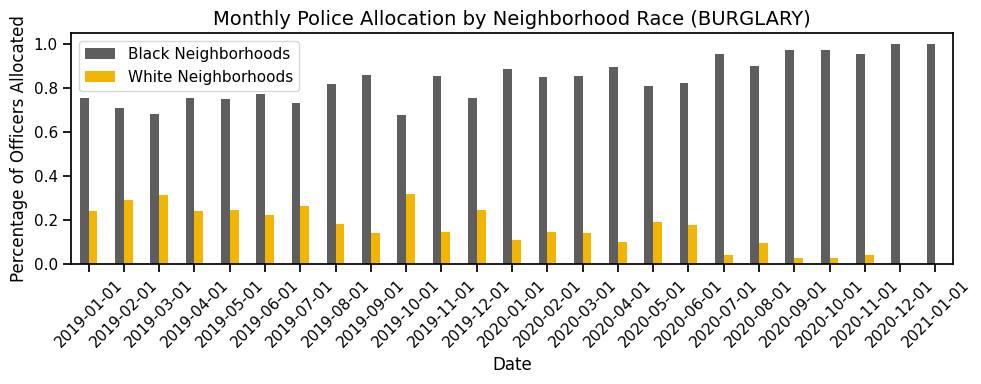

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


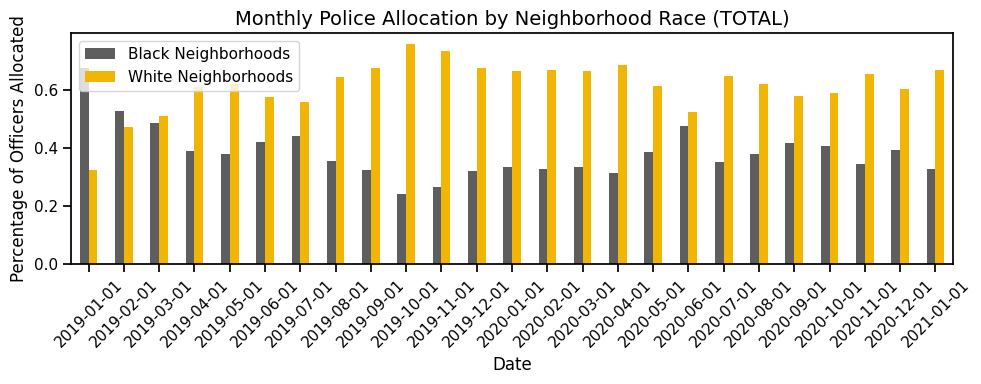

In [12]:
plot_allocation_bars(master_df,"Monthly","KDE",0.0, 40,"Percentage")

### Questions this plot answers:

#### Aim 2: Temporal Feedback Loop Effects
**1. Does bias amplify over time?** 

In this specific scenario, when Burglary records were used, we can see that as the days go on, more and more percentages of officers are assigned to Black neighborhoods, which could be an indication of amplification. In other scenarios, however, daily or monthly average police allocation is not showing a constant trend.

**2. Do different systems respond differently to feedback loops?** 

checking this plot over different scenarios, it is shown that: 
- KDE, when only detected crimes are used in Monthly police allocation settings, is either highly focused on black neighborhoods or white neighborhoods, based on the type of crime records used. 
- While KDE in other scenarios and Pred in all scenarios seem to focus on Black neighborhoods with little change in Police allocation percentage bars throughout the days/months.

#### Aim 3: Impact of Crime Type
**1. How does the choice of crime type (e.g., burglary vs total crimes) affect bias?**

nly in the case of Monthly prediction with KDE using all crime types' detected records (probability of report equal to zero) , and distributing 40 officers does the percentage of officers assigned to White neighborhoods remain higher than black neighborhoods throughout the simulation In all other scenarios using both algorithms, this percentage is constantly higher for black neighborhoods.

#### Aim 6: Baltimore-Specific Questions and Insights
**2. Are these outcomes explainable by the number of neighborhoods per group, or do they reflect preferential targeting?**

Yes. We can not forget that Baltimore has **168 Black neighborhoods** and **85 White neighborhoods** so looking at mere percentages for Baltimore, in which the number of neighborhoods with different demographics isn't balanced, will lead us to inaccurate conclusions. So let's look at the average number of Police in Black Neighborhoods vs. White neighborhoods.

---

## Average Police-Number in Black vs. White Neighborhoods Across Crime-Types (Bar-Plot)

This plot is comparing Average police allocations to Black neighborhoods vs. White neighborhoods when All crime types' records are used vs. when only Burglary records are used over the days/months of simulation.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


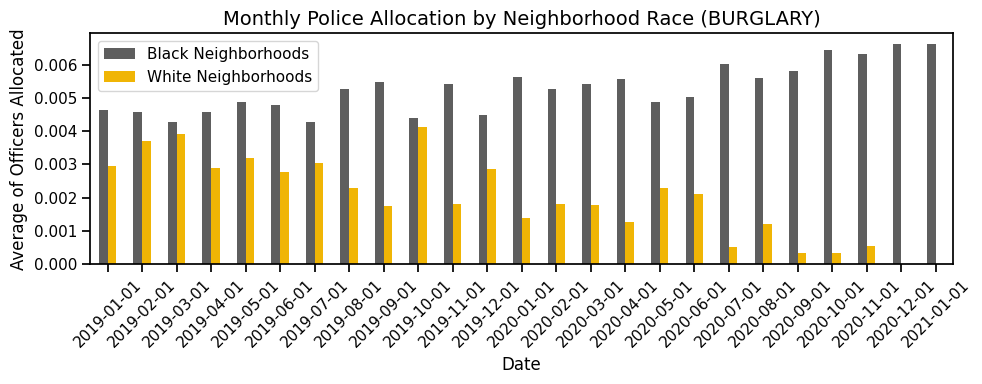

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


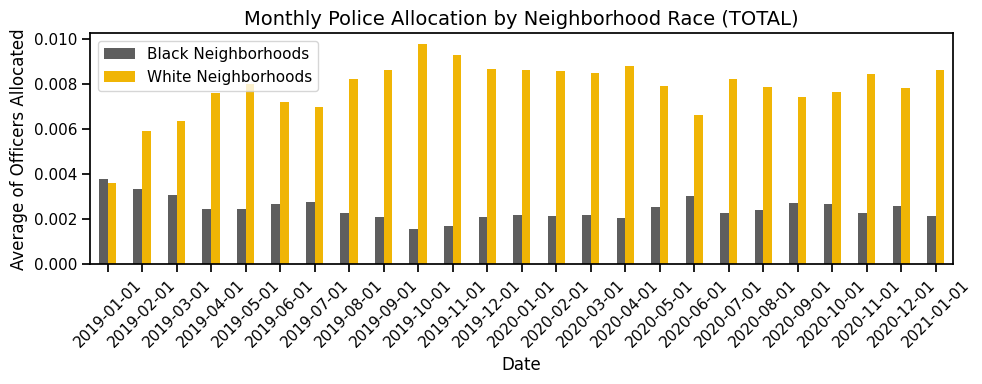

In [13]:
plot_allocation_bars(master_df,"Monthly","KDE",0.0,40,"Average" )

### Questions this plot answers:
#### Aim 2: Temporal Feedback Loop Effects

**1. Does bias amplify over time?** 

Looking at average police allocated to black neighborhood compared to white neighborhoods in the case of a monthly 40-officer allocation using KDE, with only detected crimes (report probability of zero), we see that when we use all crime types' records, as time passes average number of officers assigned to white neighborhoods grows, while for Black neighborhoods declines. However, using burglaries, this trend flips. Only these two scenarios could indicate amplification. Other scenarios there doesn't seem to be a constant growing or declining trend.</br> 

**2. Do different systems respond differently to feedback loops?** 

Based on the two scenarios of KDE with a trend, I guess for now I could say KDE seems to be more prone towards bias.

#### Aim 3: Impact of Crime Type
**1. How does the choice of crime type (e.g., burglary vs total crimes) affect bias?**

When using Burglaries to distribute 40 officers, the average number of officers Black neighborhoods get is much more than white neighborhoods. While using all crime types, this difference is much less pronounced. Then there's one extreme case of using only discovered crimes to feed the KDE model, in which White neighborhoods are getting about three times as many officers as Black neighborhoods. Therefore it is obvious that crime type does affect bias and where it concentrates resources. 
</br>
Looking at the same diagram when using PredPol in all scenarios, black neighborhoods were getting higher averages of police resources in most of the periods.
 
#### Aim 5: Is Bias Data-Driven or Model-Driven?
**1. What happens when the same data is used in different models?**

When KDE and PredPol were fed the same data, whether burglary or total crime, report probability of zero or 1, what was obvious was that Predpol showed less difference in the average number of officers allocated to black and white neighborhoods.

**2. What happens when the same model is fed different data?**

KDE's performance completely flips in response to different types of crime when the resource is scarce (40 officers). With higher resource numbers, although there's still a difference in police distribution, the concentration doesn't move from black neighborhood to white neighborhoods. 

PredPol, with either 40 officers or 400 officers, has more bias when trained on Burglaries compared to all crime types in all scenarios.

#### Aim 6: Baltimore-Specific Questions and Insights
**1. Are police consistently concentrated in racially defined neighborhoods (Black-majority, White-majority, or Other), and if so, which group receives more attention?**

In most scenarios, whether using KDE or PredPol, Black neighborhoods are getting a higher average of officers. When allocating based on Burglaries the difference is more severe. However, KDE on low officer resources, allocating based on all types of crime, filled white neighborhoods with a higher average of officers.

---

## Average Police-Share in Black vs. White Neighborhoods Across Algorithms (Line-Plot) with Feedback Effect

This plot sets two algorithms' performance side-by-side, providing us with an understanding of the trends over the days for average share of officers in Black vs. White neighborhoods. We are also looking at the feedback effect. The feedback effect in this diagram is defined as the cumulative sum of first differences in the average number of officers over the days.



In [14]:
def plot_avg_police_share_with_feedback(pMethod="Monthly", pRep= 0.0, pNum= 40, cType="TOTAL"):
    for algorithm in ALGORITHMS:
        fig, ax = plt.subplots(figsize=(10, 6))#
        data = master_df[(master_df["prediction_method"]==pMethod)&
                        (master_df["crime_type"]== cType)&
                        (master_df["Algorithm"]==algorithm)&
                        (master_df["number_of_police"]== pNum)&
                        (master_df["pReport"]==pRep)].copy()


        daily_ratios = []
        for date, group in data.groupby("Date"):
            tp = int(group["TotalPoliceOfDay"].loc[group.index[0]])
            black_ratio = group[group["IsBlack"] == 1]["police_share"].mean()
            white_ratio = group[group["IsWhite"] == 1]["police_share"].mean()
            daily_ratios.append({"Date": date, "Black Neighborhoods": black_ratio, "White Neighborhoods": white_ratio, "TotalPoliceOfDay":tp})

        ratio_df = pd.DataFrame(daily_ratios).set_index("Date")
#         ratio_df["Trendline (Black)"], black_slope, black_intercept = calc_trendline_with_params(ratio_df["Black Neighborhoods"])
#         ratio_df["Trendline (White)"], white_slope, white_intercept = calc_trendline_with_params(ratio_df["White Neighborhoods"])
        ratio_df["Trendline (Black)"], black_slope = calc_trendline(ratio_df["Black Neighborhoods"])
        ratio_df["Trendline (White)"], white_slope = calc_trendline(ratio_df["White Neighborhoods"])

        ax.plot(ratio_df.index, ratio_df["Black Neighborhoods"], label="Black Neighborhoods", linestyle='-', color=bcolor)
        ax.plot(ratio_df.index, ratio_df["White Neighborhoods"], label="White Neighborhoods", linestyle='-', color=wcolor)
#         ax.plot(ratio_df.index, ratio_df["Trendline (Black)"], label=f"Trendline (Black) (Slope: {black_slope:.4f}, Intercept: {black_intercept:.4f})", linestyle='--', color='red')
#         ax.plot(ratio_df.index, ratio_df["Trendline (White)"], label=f"Trendline (White) (Slope: {white_slope:.4f}, Intercept: {white_intercept:.4f})", linestyle='--', color='blue')
        
        ax.plot(ratio_df.index, ratio_df["Trendline (Black)"], label=f"Trendline (Black) (Slope: {black_slope:.6f})", linestyle='--', color='red')
        ax.plot(ratio_df.index, ratio_df["Trendline (White)"], label=f"Trendline (White) (Slope: {white_slope:.6f})", linestyle='--', color= COLORS[2])
        
        feedback_effect_black = (ratio_df["Black Neighborhoods"].diff().cumsum()).iloc[-1] #/ len(ratio_df)).iloc[-1]
        feedback_effect_white = (ratio_df["White Neighborhoods"].diff().cumsum() ).iloc[-1]#/ len(ratio_df)).iloc[-1]
        
        ax.text(ratio_df.index[-5], 1.01*(ratio_df["Trendline (Black)"].iloc[-1]),
                f"Feedback Effect (Black): {feedback_effect_black:.4f}", fontsize=10, color='black')
        ax.text(ratio_df.index[-5], 1.01*(ratio_df["Trendline (White)"].iloc[-1]),
                f"Feedback Effect (White): {feedback_effect_white:.4f}", fontsize=10, color='black')

        plt.title(f"Average Police Share ({algorithm}, {pNum} Officers)")
        plt.ylabel("Average Police Share")
        plt.xlabel("Date")
        plt.legend()
        plt.tight_layout()
        
        xticks = ratio_df.index[::5]
        plt.xticks(xticks, rotation=45)[::5]
        plt.tight_layout()
        
#         xtick_labels = [f"{d.strftime('%Y-%m-%d')}\nP: {ratio_df['TotalPoliceOfDay'].loc[d]}" for d in xticks]

#         ax.set_xticks(xticks)
#         ax.set_xticklabels(xtick_labels, rotation=45, ha="right")#, fontsize=9

        save_title = f'AvgPoliceShareWithFeedback_{algorithm}_{pMethod}_{cType}_{pRep}_{pNum}'
        plt.savefig(f'{RRF}/{save_title}.png')
        plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
        plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


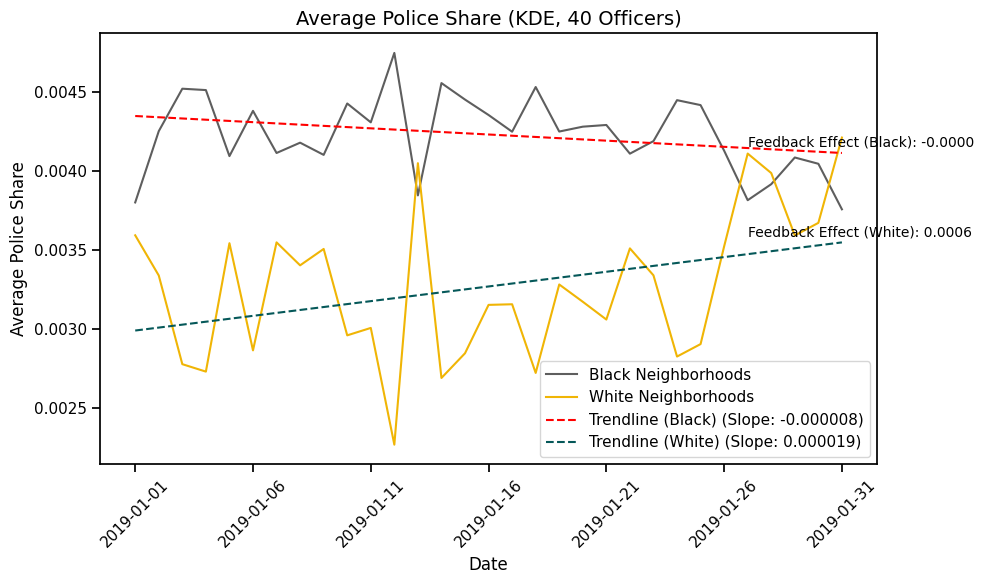

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


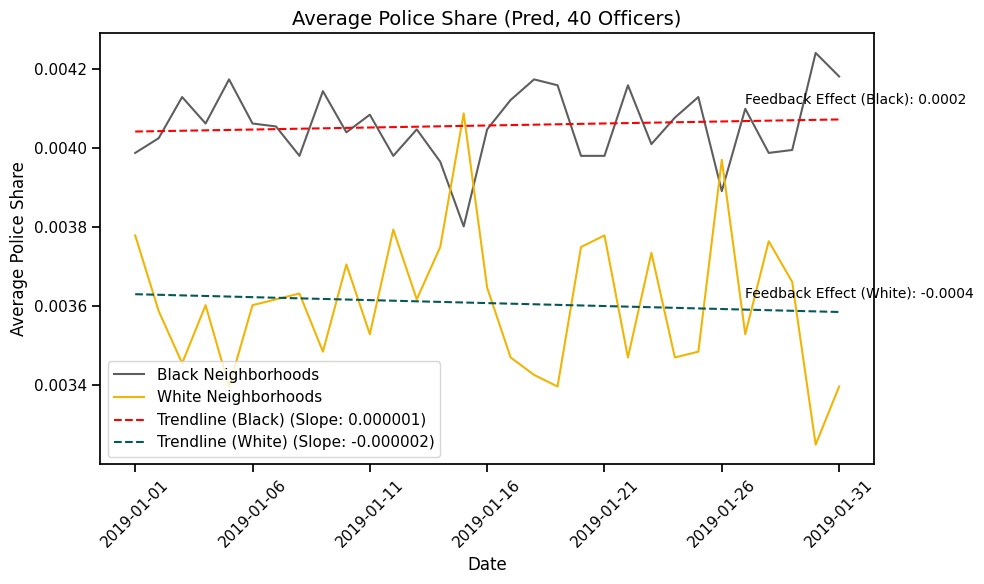

In [15]:
plot_avg_police_share_with_feedback(pMethod="Daily", pRep= 1.0, pNum= 40, cType="TOTAL")

### Questions this plot answers:

#### Aim 5: Is Bias Data-Driven or Model-Driven?
**1. What happens when the same data is used in different models?**

In **Daily prediction**, when using **burglaries**, both **KDE and PredPol** are assigning higher officer shares to **Black neighborhoods** compared to white ones. Both algorithms have a very slight slope of trendline (negative for Black neighborhoods, positive for White). 
In these scenarios, with a higher total police number (400), the difference between the average police share of Black and White neighborhoods is about 0.0005 more for KDE compared to PredPol throughout the simulation. Distributing limited resources (40 officers), however, for KDE the difference grows, while for PredPol it lessens.

Using **all types of crimes**, a higher average of officer share is given to **Black neighborhoods** compared to white ones. For PredPol, the gap grows, while for KDE, it lessens. **KDE**'s trend when using all types of crime is going toward assigning more and more to **White neighborhoods** as the days pass.

Looking at **Monthly prediction** results, when using **all types of crimes** for **KDE**, the average police share allocated to **white neighborhoods** is a minimum of 0.002 more than what is allocated to Black neighborhoods. for **PredPol** it starts with assigning Black neighborhoods more but has a **trend** with a noticeable slope going toward assigning more and more to **White neighborhoods**.

Generally, whatever the scenario or data, PredPol seems to have a smaller slope of trendline compared to KDE. With some data (Burglary records), the two models performed a bit more alike, while with other data (all crimes), they performed very differently. 

**2. What happens when the same model is fed different data?** 

In Monthly prediction method, using **all types of crimes**, we can clearly see that **White neighborhoods** are either getting the highest share from the start of the simulation or the trend is going that way. While using **Burglaries**, officers seem to concentrate or trend toward concentrating on **Black neighborhoods**.

#### Aim 6: Baltimore-Specific Questions and Insights
**1. Are police consistently concentrated in racially defined neighborhoods (Black-majority, White-majority, or Other), and if so, which group receives more attention?**

Different scenario concentrated officers in different areas. In most scenarios at the start of the simulation, higher average shares of officers were located in Black neighborhoods. In some scenarios, the trend was changing the situation (like using Burglaries in KDE) by going toward assigning more officers to white neighborhoods. PredPol, however, seemed to maintain the higher average share for Black neighborhoods.

**2. Are these outcomes explainable by the number of neighborhoods per group, or do they reflect preferential targeting?** 

The size of the groups stays the same in different simulations; however, the group with the highest police concentration changes in different scenarios. This suggests that the bias is not explainable by the number of neighborhoods, especially when the metric is averaged over neighborhoods.

---

## Standard Deviation of Police Numbers

This plot is comparing KDE and PredPol in terms of the changes in standard deviation of the number of officers assigned to each neighborhood throughout the simulation period. Police standard deviation is neither an accuracy metric nor a bias metric. However, it could show potential for bias. The lower the standard deviation, the higher the uniformity of officers' distribution. So if we have high standard deviation, we can assume that police concentration in some neighborhoods is higher compared to the rest, which could prove potential for bias.


In [16]:
def plot_std_dev(pMethod="Daily", pRep= 0.4, pNum= 40, cType="TOTAL"):
    for algorithm in ALGORITHMS:
        fig, ax = plt.subplots(figsize=(10, 6))#
        data = master_df[(master_df["prediction_method"]==pMethod)&
                        (master_df["crime_type"]== cType)&
                        (master_df["Algorithm"]==algorithm)&
                        (master_df["number_of_police"]== pNum)&
                        (master_df["pReport"]==pRep)].copy()

        std_dev = data.groupby("Date")["PoliceNum"].std()

        ax.plot(std_dev.index, std_dev, label=f"{algorithm}, {pNum} Officers", color=COLORS[8], linewidth=3)#COLORS[9]
        
        std_dev= std_dev
        trendline, slope = calc_trendline(std_dev)
        ax.plot(std_dev.index, trendline, label=f"Trendline (slope={slope:.3f})", linestyle='--', color='red', linewidth=2)
        
        """
        midpoint = len(std_dev) // 2
        std_dev1= std_dev[:midpoint]
        trendline1, slope1 = calc_trendline(std_dev1)
        ax.plot(std_dev1.index, trendline1, label=f"Trendline 1 (slope={slope1:.3f})", linestyle='--', color='red', linewidth=2)
        
        std_dev2= std_dev[midpoint:]
        trendline2, slope2 = calc_trendline(std_dev2)
        ax.plot(std_dev2.index, trendline2, label=f"Trendline 2 (slope={slope2:.3f})", linestyle='--', color='red', linewidth=2)
"""
        ax.set_title(f"Standard Deviation of Police Distribution Over Time ({algorithm})")
        ax.set_xlabel("Date")
        ax.set_ylabel("Standard Deviation")
        ax.legend()
        xticks = std_dev.index[::5]  
        plt.xticks(xticks, rotation=45)

        plt.tight_layout()
        save_title = f'PoliceStdDev_{algorithm}_{pMethod}_{cType}_{pNum}_{pRep}'
        plt.savefig(f'{RRF}/{save_title}.png')
        plt.savefig(f'{RRF}/{save_title}.eps', format='eps')

        plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


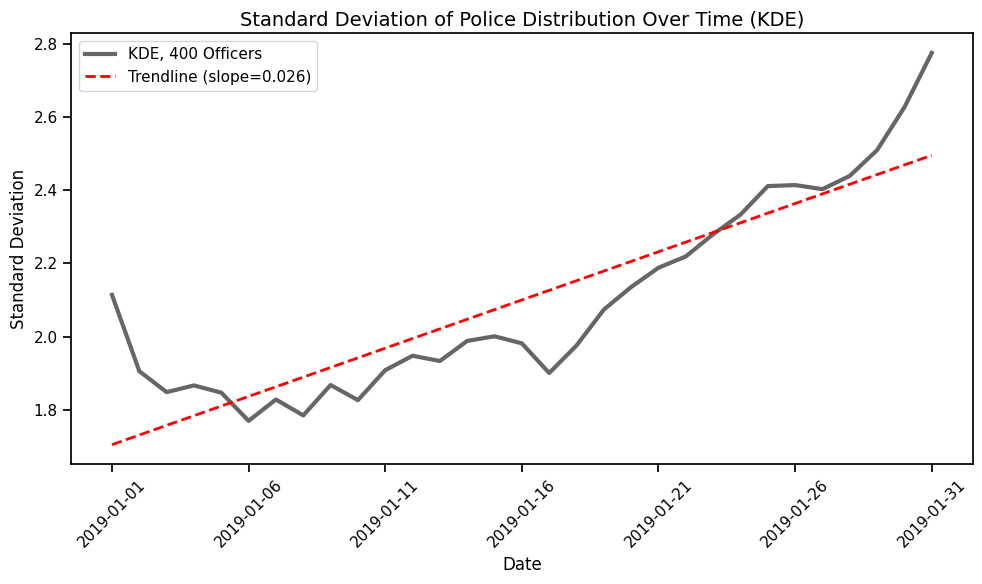

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


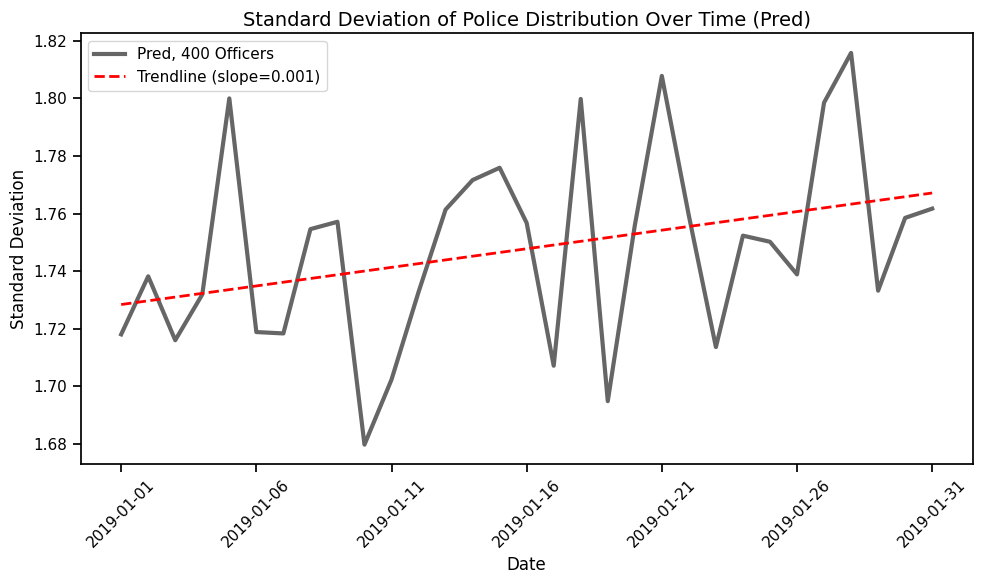

In [17]:
plot_std_dev(pMethod="Daily", pRep= 1.0, pNum= 400, cType="TOTAL")

### Questions this plot answers:
#### Aim 1: Fairness and Accuracy Comparison
**1. How does KDE compare to PredPol in terms of fairness and accuracy across scenarios?**

since standard deviation is not exactly a fairness metric, here we analyzed potential for bias. In all scenarios, KDE's trendline has a steeper slope compared to PredPol, showing more intensity of changes in the uniformity of police distribution among neighborhoods. Looking at KDE's plots in different scenarios, we could see the trend visually even without a trendline. PredPol, on the other hand, fluctuated so much in some of the scenarios that without a trendline it wouldn't have been easy to determine if there's a rising or declining trend.

#### Aim 2: Temporal Feedback Loop Effects
**1. Does bias amplify over time?**

The potential for bias seems clear for KDE. For Predpol though, despite the mostly positive trendline slope, due to the fluctuations, concluding on this matter will be left after analyzing more diagrams. 

**2. Do different systems respond differently to feedback loops?** 

Yes, Predpol and KDE are showing a clear difference in the uniformity of police distribution.

#### Aim 4: Effect of Report Probability
**1. How does under-reporting affect model performance and fairness?** 

In most scenarios, by changing report probability from 0 to 1, the slope of the trendline decreased, meaning higher report probability lowers the potential for bias.

---

## Report Probability's Effect on Police-Distribution's Uniformity

This time to check out uniformity of police distribution, we look at gini- coefficient, so we check out the uniformity with another metric as well. We are only studying daily prediction method here, beacuse for monthly prediction the amplification of bias is too evident that it doesn't need a closer look.

In [18]:
def gini_coefficient(x):
    """Compute the Gini coefficient of a numpy array trapizoidal way (1-2B)
    lorenzo curve is the curve created when you draw a special diagram of your array containing n numbers.
    your sorted array= [x1, x2, ..., xn]
    This diagram on its x axis has numbers: [1/n, 2/n, ..., n/n], 
    and on its y axis it has: [x1, x1+x2, ..., sigma(i=1 to n) xi] 
    the area under lorenzo curve is called B.
    It has been proven that 1-2B shows the extent of inequality of the numbers. 
    0 is perfect equality, while 1 is perfect inequality.
    """
    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * x)) / (n * np.sum(x)) if np.sum(x) > 0 else np.nan


In [19]:
gini_df = master_df[master_df["prediction_method"]=="Daily"].groupby(["Algorithm", "Date", "pReport", "prediction_method", "crime_type", "number_of_police"]).apply(
    lambda df: gini_coefficient(df["police_share"].values)
).reset_index(name="PoliceGini")
display(gini_df)


,Algorithm,Date,pReport,prediction_method,crime_type,number_of_police,PoliceGini
0,KDE,2019-01-01,0.0,Daily,BURGLARY,40,0.888321
1,KDE,2019-01-01,0.0,Daily,BURGLARY,400,0.744355
2,KDE,2019-01-01,0.0,Daily,TOTAL,40,0.880859
3,KDE,2019-01-01,0.0,Daily,TOTAL,400,0.669817
4,KDE,2019-01-01,0.1,Daily,BURGLARY,40,0.888321
...,...,...,...,...,...,...,...
2723,Pred,2019-01-31,0.9,Daily,TOTAL,400,0.513662
2724,Pred,2019-01-31,1.0,Daily,BURGLARY,40,0.569482
2725,Pred,2019-01-31,1.0,Daily,BURGLARY,400,0.522362
2726,Pred,2019-01-31,1.0,Daily,TOTAL,40,0.555762


In [20]:
def plot_police_gini_vs_pReport(pNum=40, cType="TOTAL"):
    filtered = gini_df[
        (gini_df["crime_type"] == cType) &
        (gini_df["number_of_police"] == pNum)
    ].copy()

    avg_gini = filtered.groupby(["pReport", "Algorithm"])["PoliceGini"].mean().reset_index()

    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 10))
    
    pred_data = avg_gini[avg_gini["Algorithm"] == "Pred"]
    sns.lineplot(
        data= pred_data,
        x="pReport",
        y="PoliceGini",
        marker="o",
        ax = axes[0],
        color=palette_dict["Pred"],
        label="PredPol"
    )
    axes[0].set_title("Pred - Police Gini Coefficient")
    trendline1, slope1 = calc_trendline(pred_data["PoliceGini"])
    axes[0].plot(pred_data["pReport"], trendline1, label=f"Trendline (slope={slope1:.4f})", linestyle='--', color=COLORS[8], linewidth=2)
    axes[0].legend(loc="best")
    
    KDE_data = avg_gini[avg_gini["Algorithm"] == "KDE"]
    sns.lineplot(
        data= KDE_data,
        x="pReport",
        y="PoliceGini",
        marker="o",
        ax = axes[1],
        color=palette_dict["KDE"],
        label="KDE"
    )
    axes[1].set_title("KDE - Police Gini Coefficient")
    trendline2, slope2 = calc_trendline(KDE_data["PoliceGini"])
    axes[1].plot(KDE_data["pReport"], trendline2, label=f"Trendline (slope={slope2:.4f})", linestyle='--', color=COLORS[8], linewidth=2)

    axes[1].set_xlabel("Reporting Probability (pReport)")
    axes[1].legend(loc="best")
    
    for ax in axes:
        ax.set_ylabel("Average Police Gini")
        
    fig.suptitle(f"Police Gini vs Reporting Probability\n({cType}, {pNum} Officers)", fontsize=14)
    
    plt.tight_layout()
    
    save_title = f'PoliceGini_overProbsReports_Daily_{cType}_{pNum}'
    plt.savefig(f'{RRF}/{save_title}.png')
    plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
    plt.show()



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


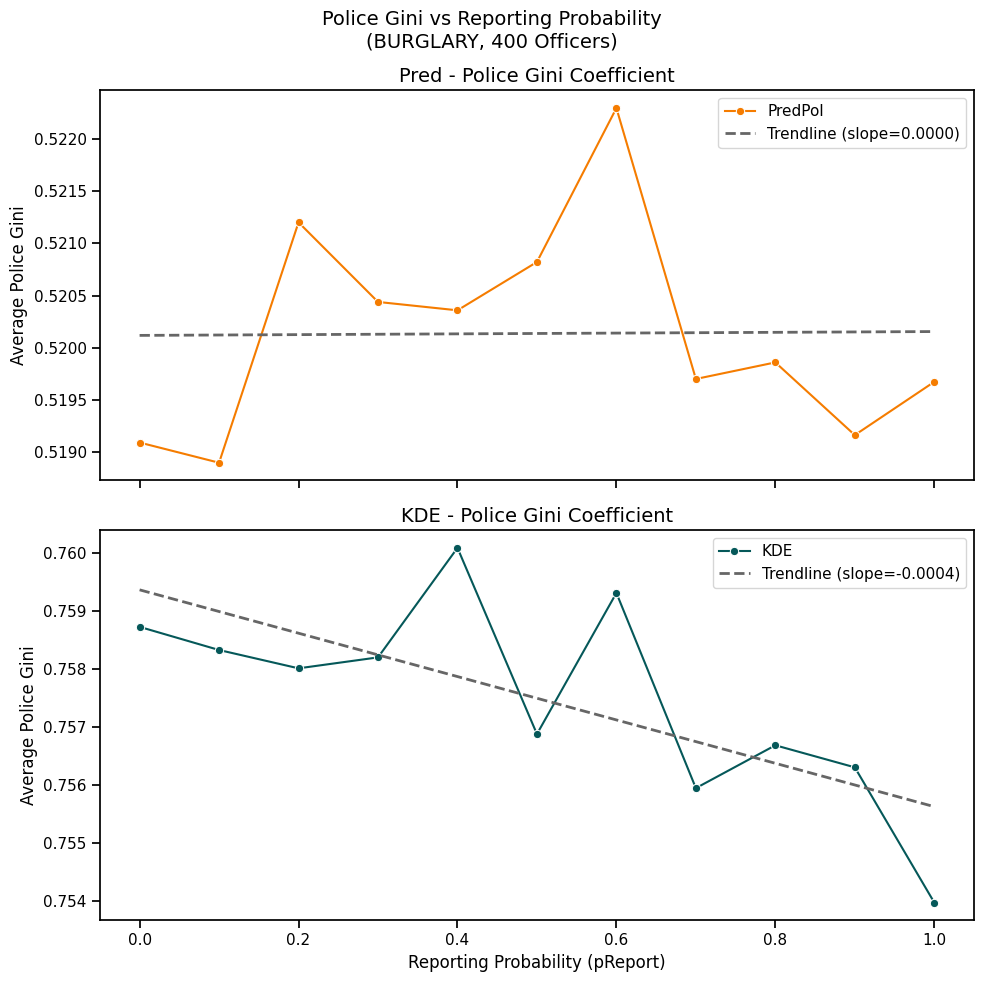

In [21]:
plot_police_gini_vs_pReport(pNum=400, cType="BURGLARY")

Zero gini-coefficient means complete in-equality while one is perfect equality. Looking at different scenarios it seems like some scenarios show a falling trend while others have a rising trend for average police distribution's gini coefficient over rising report probabilities. Therefor surprisingly we can **not** conclude that under reporting is causing officers to concentrate in specific neighborhoods with high certainty. 

What we can say is that KDE in all but one scenario (distributing 400 officers using all crime records) had a falling trend. PredPol on ther hand had a falling trend when all crime records were used but had either no trend or a slight rising trend when Burglary records were used.  

---

 ## Daily Coverage Accuracy and Fairness Gap (line plots)

This diagram plots two metrics: </br>
  1. Coverage Accuracy: percentage of crimes that are detected
  2. Cumulative Absolute Fairness Gap: cumulative absolute difference between police-share and crime-share 
  

In [22]:
def plot_coverageAccuracy_and_fairnessGap(pMethod="Daily", pRep= 0.4, pNum= 40, cType="TOTAL", based_on="Cumulative"):
    """
    based_on: can be either "Cumulative" or "Average", to calculate cumulative absolute fairness gap or Average absolute fairness gap
    """
    data = master_df[
        (master_df["crime_type"] == cType) &
        (master_df["number_of_police"] == pNum) &
        (master_df["pReport"] == pRep) &
        (master_df["prediction_method"]== pMethod)
    ].copy()

    base_slice= data.groupby(["Date", "Algorithm"]).agg(
            TotalCrime=("CrimesNum", "sum"),
            TotalDetected=("DetectedNum", "sum"),
            Average_abs_fairness_gap=("fairness_gap", lambda x: x.abs().mean()),
            Cumulative_abs_fairness_gap=("fairness_gap", lambda x: x.abs().sum()),
        ).reset_index()
    base_slice["day_coverage_accuracy"] = base_slice["TotalDetected"] / base_slice["TotalCrime"]
    
    for metric,label in {f"{based_on}_abs_fairness_gap":f"{based_on} Absolute Fairness Gap",
                   "day_coverage_accuracy":"Day's coverage accuracy"}.items():
        fig, ax = plt.subplots(1, 1, figsize=(10, 6), sharex=False)

        sns.lineplot(
            data=base_slice,
            x="Date",
            y=metric,
            hue="Algorithm",
            palette=palette_dict,
            ax=ax,
            errorbar=None,
            linewidth=2
        )
        for algo in base_slice["Algorithm"].unique():
            df_algo = base_slice[base_slice["Algorithm"] == algo]
            trendline, slope = calc_trendline(df_algo[metric])

            ax.plot(df_algo["Date"], trendline, linestyle="--", linewidth=2, color=palette_dict[algo], label=f"{algo} Trend")

    
        ax.set_title(f"{label} Over Time")
        ax.set_ylim(base_slice[metric].min(), base_slice[metric].max())
        ax.set_ylabel(label)
        ax.axhline(0, color="gray", linestyle="--", linewidth=1)
        ax.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
    
        save_title = f'{metric}OverTime_{pRep}_{pMethod}_{cType}_{pNum}'
        plt.savefig(f'{RRF}/{save_title}.png')
        plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
        plt.show()
        
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14), sharex=False)

#     sns.lineplot(
#         data=base_slice,
#         x="Date",
#         y=f"{based_on}_abs_fairness_gap",
#         hue="Algorithm",
#         #style="Algorithm",
#         palette=palette_dict,
#         ax=ax1,
#         errorbar=None,
#         linewidth=2
#     )
#     for algo in base_slice["Algorithm"].unique():
#         df_algo = base_slice[base_slice["Algorithm"] == algo]
#         trendline, slope = calc_trendline(df_algo[f"{based_on}_abs_fairness_gap"])
    
#         ax1.plot(df_algo["Date"], trendline, linestyle="--", linewidth=2, color=palette_dict[algo], label=f"{algo} Trend")

    
#     ax1.set_title(f"{based_on} Absolute Fairness Gap Over Time")
#     ax1.set_ylim(base_slice[f"{based_on}_abs_fairness_gap"].min(), base_slice[f"{based_on}_abs_fairness_gap"].max())
#     ax1.set_ylabel(f"{based_on} abs fairness gap")
#     ax1.axhline(0, color="gray", linestyle="--", linewidth=1)
#     ax1.tick_params(axis='x', rotation=45)

#     sns.lineplot(
#         data=base_slice,
#         x="Date",
#         y="day_coverage_accuracy",
#         hue="Algorithm",
#         #style=,
#         palette=palette_dict,
#         ax=ax2,
#         errorbar=None,
#         linewidth=2
#     )
#     ax2.set_title("Day's coverage accuracy over time")
#     ax2.set_ylim(base_slice["day_coverage_accuracy"].min(), base_slice["day_coverage_accuracy"].max())
#     ax2.set_ylabel("day_coverage_accuracy")
#     ax2.set_xlabel("Date")
#     ax2.axhline(0, color="gray", linestyle="--", linewidth=1)
#     ax2.tick_params(axis='x', rotation=45)


#     plt.tight_layout()
#     plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


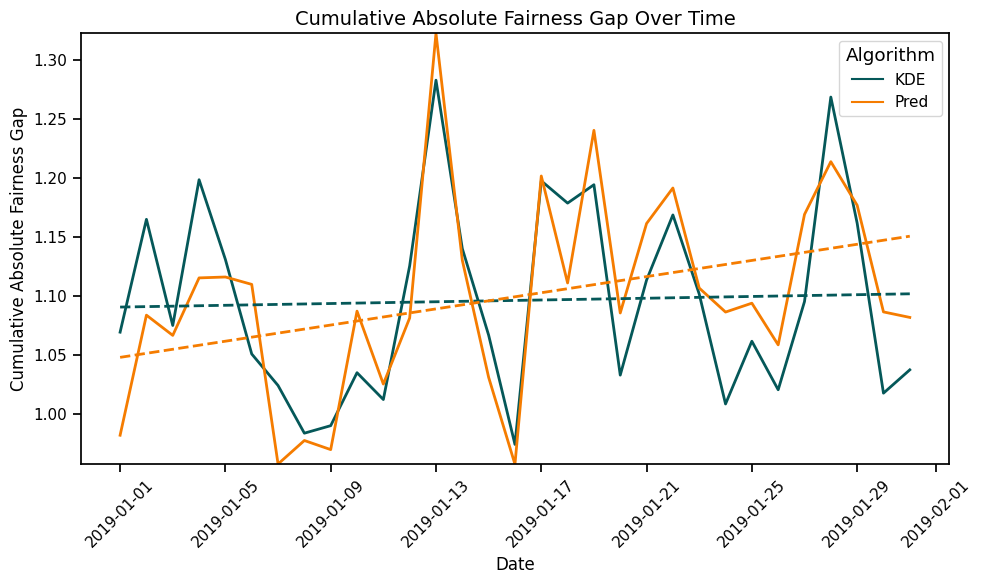

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


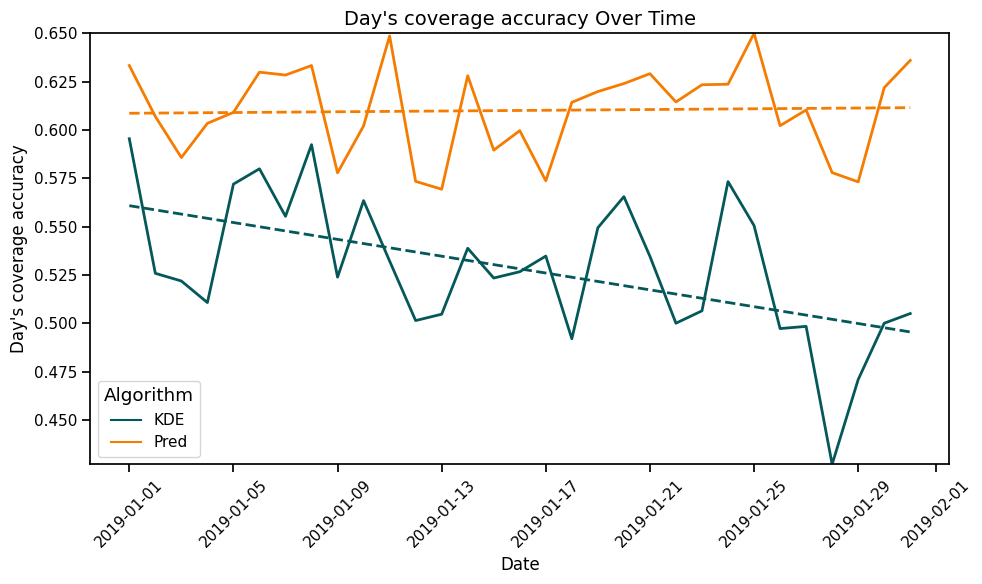

In [23]:
plot_coverageAccuracy_and_fairnessGap(pMethod="Daily", pRep= 1.0, pNum= 400, cType="TOTAL", based_on="Cumulative")


### Questions this plot answers:
The questions are being answered based on Daily prediction method.
#### Aim 1: Fairness and Accuracy Comparison
**1. How does KDE compare to PredPol in terms of fairness and accuracy across scenarios?**

PredPol seems to have higher daily coverage accuracy across scenarios. Cumulative absolute fairness gap, on the other hand, is not that easy to interpret. Both algorithms are performing very closely in terms of the fairness gap. It seems when Burglary records are used, PredPol maintains a higher value. We believe if fairness is defined as equal police share to crime share, like in this diagram, there's a threshold for a system's unfairness, within which the system performs its best; however, passing that threshold, the accuracy drops. When using Total crimes, comparing the fairness gap for PredPol and KDE is not visually possible.

**2. Are more accurate systems necessarily fairer?**

As it was explained in the case of Burglaries, PredPol was less fair (higher cumulative absolute fairness gap) while being noticeably more accurate on a **Daily** basis. </br>
**Daily** is being emphasized because a fair daily distribution doesn't guarantee a period's fair distribution. For example, if we have two neighborhoods that are maintaining a zero crime record status in a period in the simulation, and every once in a while they are getting one lone officer, the algorithm's fairness here lies in assigning the same number of officers to these neighborhoods in that period. Therefore, these algorithms should be analyzed over longer periods as well. Many neighborhoods have zero daily crime records in Baltimore. In order to have a more logically meaningful analysis, we are going to look at weekly values of these metrics next.

---
## Creating Weekly Reports Dataframes

Here we are using master_df to create weekly reports, including the values for each neighborhoods' fairness gap in a week in a scenario. Two dataframes are created here:
1. weekly_Nei_df: This dataframe has Neighborhood + scnenario + weekLabel as index. It contains weekly values for number of officers, number of crimes, number of crimes detected, police share, crime share, fairness gap, etc.
2. weekly_df: This dataframe has scenario + weeklabel as index. It contains week's cumulative absolute fairness gap of all neighborhoods, average absolute fairness gap, etc.

In [24]:
base_slice = master_df[master_df["prediction_method"]=="Daily"].copy()
scen =scenario_cols.copy()

base_slice["Week"] = base_slice["Date"].dt.to_period("W").apply(lambda r: r.start_time)
week_order = {week: f"Week {i+1}" for i, week in enumerate(sorted(base_slice["Week"].unique()))}
base_slice["WeekLabel"] = base_slice["Week"].map(week_order)

group_cols = ["WeekLabel","Week"]+ scen
weekly_Nei_df = base_slice.groupby(group_cols+["Neighborhood","IsBlack","IsWhite"]).agg(
    weekly_policeNum=("PoliceNum", "sum"),
    weekly_crimesNum=("CrimesNum", "sum"),
    weekly_DetectedNum=("DetectedNum", "sum"),
    #weekly_total_crime=("CrimesNum", "sum")
).reset_index()

weekly_df = weekly_Nei_df.groupby(group_cols).agg(
    weekly_total_police=("weekly_policeNum", "sum"),
    weekly_total_crime=("weekly_crimesNum", "sum"),
    weekly_total_Detected=("weekly_DetectedNum", "sum"),
).reset_index()

weekly_Nei_df = weekly_Nei_df.merge(weekly_df, on=group_cols, how="left")
weekly_Nei_df["weekly_crime_share"]= weekly_Nei_df["weekly_crimesNum"]/weekly_Nei_df["weekly_total_crime"]
weekly_Nei_df["weekly_police_share"]= weekly_Nei_df["weekly_policeNum"]/weekly_Nei_df["weekly_total_police"]
weekly_Nei_df["weekly_fairness_gap"]=weekly_Nei_df["weekly_police_share"] - weekly_Nei_df["weekly_crime_share"]
weekly_Nei_df["weekly_abs_fairness_gap"]=weekly_Nei_df["weekly_fairness_gap"].abs()

weekly_df["coverage_accuracy"] = (
    (weekly_df["weekly_total_Detected"] + 1) / (weekly_df["weekly_total_crime"] + 1)
)

a= weekly_Nei_df.groupby(group_cols).agg(
    Average_abs_fairness_gap = ("weekly_abs_fairness_gap","mean"),
    Cumulative_abs_fairness_gap = ("weekly_abs_fairness_gap", "sum")
    ).reset_index()

weekly_df= weekly_df.merge(a, on=group_cols, how="left")
display(weekly_df)
display(weekly_Nei_df)

,WeekLabel,Week,Algorithm,prediction_method,crime_type,number_of_police,pReport,weekly_total_police,weekly_total_crime,weekly_total_Detected,coverage_accuracy,Average_abs_fairness_gap,Cumulative_abs_fairness_gap
0,Week 1,2018-12-31,KDE,Daily,BURGLARY,40,0.0,227.45,95.0,16.90,0.186458,0.004973,1.273131
1,Week 1,2018-12-31,KDE,Daily,BURGLARY,40,0.1,227.85,95.0,17.50,0.192708,0.005005,1.281314
2,Week 1,2018-12-31,KDE,Daily,BURGLARY,40,0.2,228.20,95.0,17.10,0.188542,0.005015,1.283722
3,Week 1,2018-12-31,KDE,Daily,BURGLARY,40,0.3,228.75,95.0,18.20,0.200000,0.004943,1.265413
4,Week 1,2018-12-31,KDE,Daily,BURGLARY,40,0.4,228.60,95.0,17.95,0.197396,0.004939,1.264318
...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,Week 5,2019-01-28,Pred,Daily,TOTAL,400,0.6,1600.00,415.0,246.10,0.593990,0.002396,0.613297
436,Week 5,2019-01-28,Pred,Daily,TOTAL,400,0.7,1600.00,415.0,251.30,0.606490,0.002361,0.604491
437,Week 5,2019-01-28,Pred,Daily,TOTAL,400,0.8,1600.00,415.0,250.70,0.605048,0.002369,0.606484
438,Week 5,2019-01-28,Pred,Daily,TOTAL,400,0.9,1600.00,415.0,243.35,0.587380,0.002404,0.615310


,WeekLabel,Week,Algorithm,prediction_method,crime_type,number_of_police,pReport,Neighborhood,IsBlack,IsWhite,weekly_policeNum,weekly_crimesNum,weekly_DetectedNum,weekly_total_police,weekly_total_crime,weekly_total_Detected,weekly_crime_share,weekly_police_share,weekly_fairness_gap,weekly_abs_fairness_gap
0,Week 1,2018-12-31,KDE,Daily,BURGLARY,40,0.0,ABELL,False,True,0.00,0.0,0.00,227.45,95.0,16.90,0.000000,0.000000,0.000000,0.000000
1,Week 1,2018-12-31,KDE,Daily,BURGLARY,40,0.0,ALLENDALE,True,False,0.25,0.0,0.00,227.45,95.0,16.90,0.000000,0.001099,0.001099,0.001099
2,Week 1,2018-12-31,KDE,Daily,BURGLARY,40,0.0,ARCADIA,False,True,0.00,0.0,0.00,227.45,95.0,16.90,0.000000,0.000000,0.000000,0.000000
3,Week 1,2018-12-31,KDE,Daily,BURGLARY,40,0.0,ARLINGTON,True,False,0.00,0.0,0.00,227.45,95.0,16.90,0.000000,0.000000,0.000000,0.000000
4,Week 1,2018-12-31,KDE,Daily,BURGLARY,40,0.0,ARMISTEAD GARDENS,False,True,1.45,0.0,0.00,227.45,95.0,16.90,0.000000,0.006375,0.006375,0.006375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112635,Week 5,2019-01-28,Pred,Daily,TOTAL,400,1.0,WRENLANE,True,False,1.45,1.0,0.15,1600.00,415.0,249.35,0.002410,0.000906,-0.001503,0.001503
112636,Week 5,2019-01-28,Pred,Daily,TOTAL,400,1.0,WYMAN PARK,False,True,1.90,1.0,0.10,1600.00,415.0,249.35,0.002410,0.001187,-0.001222,0.001222
112637,Week 5,2019-01-28,Pred,Daily,TOTAL,400,1.0,WYNDHURST,False,True,0.50,0.0,0.00,1600.00,415.0,249.35,0.000000,0.000313,0.000313,0.000313
112638,Week 5,2019-01-28,Pred,Daily,TOTAL,400,1.0,YALE HEIGHTS,True,False,4.35,2.0,0.85,1600.00,415.0,249.35,0.004819,0.002719,-0.002101,0.002101


## Weekly Coverage Accuracy and Fairness Gap (line plots)
This time we try the ploting the same metrics of Coverage accuracy and cumulative absolute fairness gap but over a weeks period.

In [25]:
def plot_coverageAccuracy_and_fairnessGap_weekly(pRep= 0.4, pNum= 40, cType="TOTAL", based_on="Cumulative"):
    
    base_slice = weekly_df[
        (weekly_df["crime_type"] == cType) &
        (weekly_df["number_of_police"] == pNum) &
        (weekly_df["pReport"]==pRep)
    ].copy()

    fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    sns.lineplot(
        data=base_slice,
        x="WeekLabel",
        y=f"{based_on}_abs_fairness_gap",
        hue="Algorithm",
        ax=axs[0],
        palette=palette_dict,
        errorbar = None
    )
    axs[0].set_title(f"Weekly {based_on} Absolute Fairness Gap")
    axs[0].set_ylabel(f"{based_on} Abs Fairness Gap")

    sns.lineplot(
        data=base_slice,
        x="WeekLabel",
        y="coverage_accuracy",
        hue="Algorithm",
        ax=axs[1],
        palette=palette_dict,
        errorbar = None
    )
    axs[1].set_title("Weekly Coverage Accuracy (Detected / Crimes)")
    axs[1].set_ylabel("Coverage Accuracy")

    plt.tight_layout()
    
    save_title = f'AccuracyVs{based_on}FairnessOverTime_{pRep}_{cType}_{pNum}'
    plt.savefig(f'{RRF}/{save_title}.png')
    plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
    plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


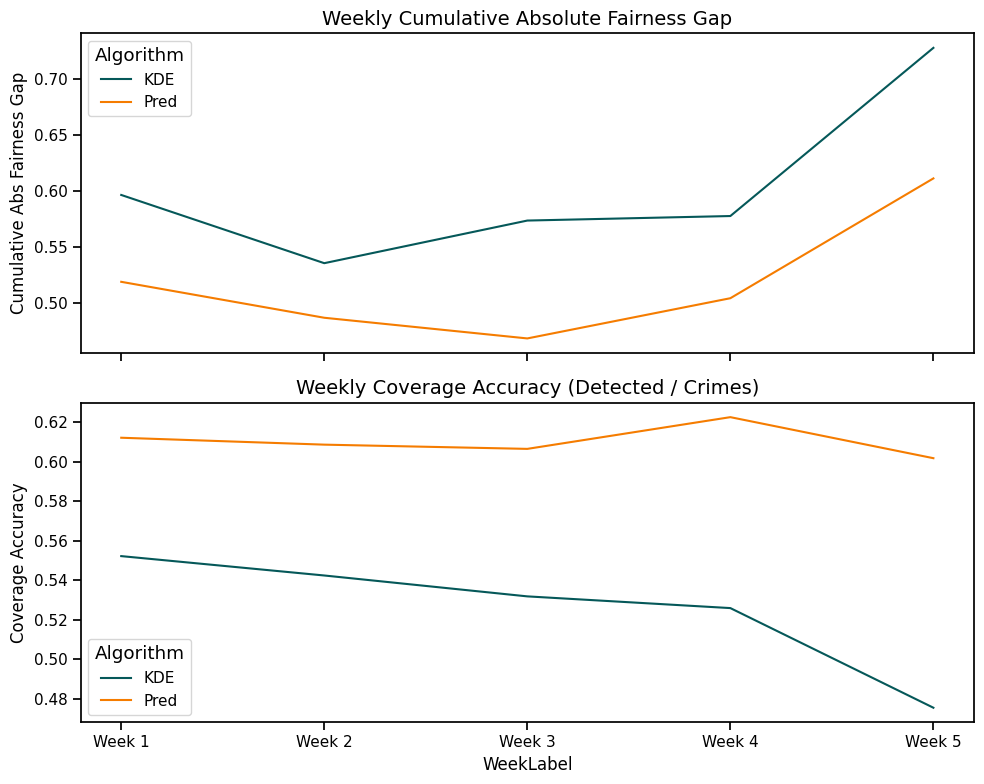

In [26]:
plot_coverageAccuracy_and_fairnessGap_weekly(pRep= 1.0, pNum= 400, cType="TOTAL", based_on="Cumulative")



### Questions this plot answers:
#### Aim 1: Fairness and Accuracy Comparison
**1. How does KDE compare to PredPol in terms of fairness and accuracy across scenarios?**

For weekly analysis, the accuracy of PredPol is higher in almost every scenario. It is also mostly fairer than KDE, but there are some scenarios in which KDE becomes fairer. By "fairer," we mean a lower cumulative fairness gap.

**2. Are more accurate systems necessarily fairer?**

In most of these diagrams, the more accurate system, PredPol, happens to be the fairer algorithm, but there are some cases in which this does not hold true based on these plots.

#### Aim 2: Temporal Feedback Loop Effects
**1. Does bias amplify over time?** 

In these weekly analysis, for both algorithms, the fairness gap lowers at first but then takes a turn toward a higher gap with a steeper slope.

**2. Do different systems respond differently to feedback loops?** 

Although both algorithms seem to follow the same general trend, KDE has higher slopes in its trends most of the time, indicating a less stable response to the feedback effect.

#### Aim 3: Impact of Crime Type
**1. How does the choice of crime type (e.g., burglary vs total crimes) affect bias?** 

Most of the cases that KDE becomes fairer, the crime records used is Burglaries, while when using Total crime records, PredPol generally stays fairer and more accurate. When using all crime records fairness gap for both algorithms is less compared to when Burglary records are used.

#### Aim 5: Is Bias Data-Driven or Model-Driven?
**1. What happens when the same data is used in different models?**

As it was explained PredPol and KDE had different accuracy and fairness levels.

**2. What happens when the same model is fed different data?**

As it was explained different data changes the fairness levels and accuracy.

---

## Average Absolute Fairness Gap Vs.  Coverage Accuracy (scatter plot)

In this plot, each data point represents a week in the simulation. More recent days have higher opacity, while earlier days in the simulation are more transparent.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


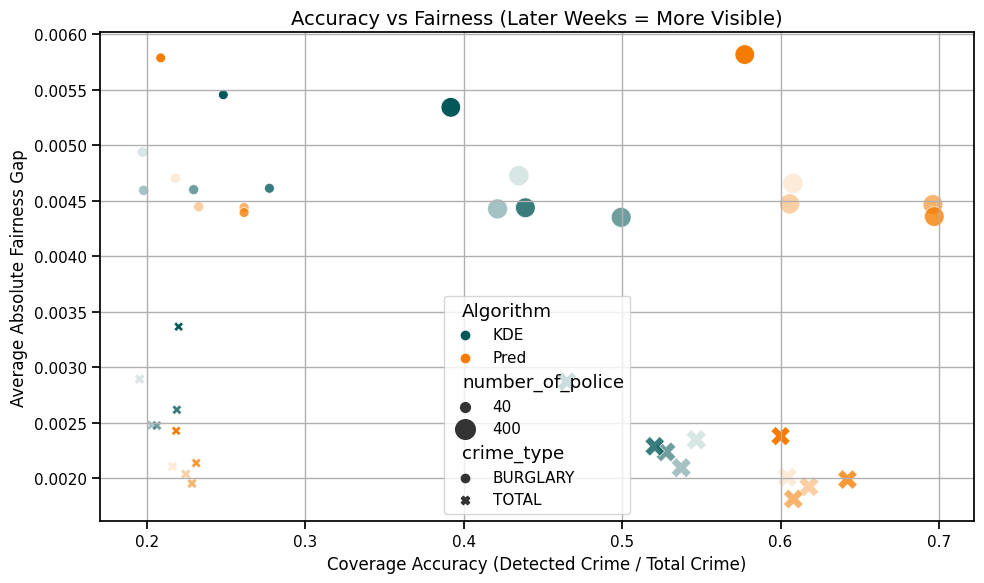

In [27]:
subset = weekly_df[
    (weekly_df["pReport"].isin([0.4]))
].copy()
# subset = weekly_df[
#     (weekly_df["pReport"].isin([0.1, 0.9]))&
#     (weekly_df["number_of_police"]==400)
# ].copy()
subset["alpha"] = 0.15 + 0.85 * (subset["Week"] - subset["Week"].min()) / (subset["Week"].max() - subset["Week"].min())

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=subset,
    x="coverage_accuracy",
    y="Average_abs_fairness_gap",
    hue="Algorithm",
    style="crime_type",
    size="number_of_police", #"pReport",
    sizes=(50, 200),
    palette=palette_dict,
    alpha=subset["alpha"]
)

plt.title("Accuracy vs Fairness (Later Weeks = More Visible)")
plt.xlabel("Coverage Accuracy (Detected Crime / Total Crime)")
plt.ylabel("Average Absolute Fairness Gap")
plt.grid(True)

plt.tight_layout()
    
save_title = f'AccuracyVsAverageAbsFairnessOverTime_0.4'
plt.savefig(f'{RRF}/{save_title}.png')
plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
plt.show()


### Questions this plot answers:
#### Aim 1: Fairness and Accuracy Comparison
**1. How does KDE compare to PredPol in terms of fairness and accuracy across scenarios?** 

Looking at these weekly values appearing on the scatter plot, KDE points are obviously at lower values relative to comparative PredPol points when it comes to accuracy. For fairness, however, it is a bit less clear.

**2. Are more accurate systems necessarily fairer?**

On this diagram It is clearly shown that accurate systems are emerging all over the average fairness gap spectrum.

#### Aim 2: Temporal Feedback Loop Effects

**1. Does bias amplify over time?**

It is evident that More opaque points stand generally higher than the others, indicating the average absolute fairness gap grows over time.  

#### Aim 3: Impact of Crime Type

**1. How does the choice of crime type (e.g., burglary vs total crimes) affect bias?**

Using Burglary records the fairness gap is higher for both algorithms. but we can't conclude about the data's effect on accuracy levels with confidence based on this diagram.

#### Aim 4: Effect of Report Probability

**1. How does under-reporting affect model performance and fairness?**

There isn't visible clustering of higher report probability points compared to the rest on this diagram.

Note: Police Number is not affecting fairness but does result in higher coverage accuracy, as expected.

---

## Further Weekly Analysis
To make it more clear Let's answer more questions. How many times is which model fairer or more accurate? What is the average difference when KDE is fairer and what is it when PredPol is fairer?

We are answering these questions using a new dataframe, called **weekly_scenario_summary** containing average difference between coverage accuracy of the two algorithm, **avg_accuracy_diff**, and average difference between the cumulative fairness gap of the two, **avg_fairness_diff**, for each scenario.


In [28]:
pivot_df = weekly_df.pivot_table(
    index=["WeekLabel", "crime_type", "number_of_police", "pReport"],
    columns="Algorithm",
    values=["Cumulative_abs_fairness_gap", "coverage_accuracy"]
).reset_index()

pivot_df.columns = ['_'.join(col).strip('_') for col in pivot_df.columns.values]

pivot_df["fairness_gap_diff"] = pivot_df["Cumulative_abs_fairness_gap_Pred"] - pivot_df["Cumulative_abs_fairness_gap_KDE"]
pivot_df["accuracy_diff"] = pivot_df["coverage_accuracy_Pred"] - pivot_df["coverage_accuracy_KDE"]
display(pivot_df)

,WeekLabel,crime_type,number_of_police,pReport,Cumulative_abs_fairness_gap_KDE,Cumulative_abs_fairness_gap_Pred,coverage_accuracy_KDE,coverage_accuracy_Pred,fairness_gap_diff,accuracy_diff
0,Week 1,BURGLARY,40,0.0,1.273131,1.219912,0.186458,0.213021,-0.053219,0.026563
1,Week 1,BURGLARY,40,0.1,1.281314,1.211601,0.192708,0.210938,-0.069713,0.018229
2,Week 1,BURGLARY,40,0.2,1.283722,1.188246,0.188542,0.213021,-0.095476,0.024479
3,Week 1,BURGLARY,40,0.3,1.265413,1.191404,0.200000,0.229688,-0.074009,0.029687
4,Week 1,BURGLARY,40,0.4,1.264318,1.204079,0.197396,0.218229,-0.060239,0.020833
...,...,...,...,...,...,...,...,...,...,...
215,Week 5,TOTAL,400,0.6,0.727562,0.613297,0.471635,0.593990,-0.114265,0.122356
216,Week 5,TOTAL,400,0.7,0.723423,0.604491,0.469952,0.606490,-0.118933,0.136538
217,Week 5,TOTAL,400,0.8,0.727101,0.606484,0.478365,0.605048,-0.120617,0.126683
218,Week 5,TOTAL,400,0.9,0.734036,0.615310,0.478486,0.587380,-0.118726,0.108894


In [29]:
weekly_scenario_summary = pivot_df.groupby([
    "crime_type", "number_of_police", "pReport"
]).agg(
    avg_fairness_diff=("fairness_gap_diff", "mean"),
    avg_accuracy_diff=("accuracy_diff", "mean")
).reset_index()
display(weekly_scenario_summary)

,crime_type,number_of_police,pReport,avg_fairness_diff,avg_accuracy_diff
0,BURGLARY,40,0.0,-0.018687,0.014738
1,BURGLARY,40,0.1,-0.018506,0.011304
2,BURGLARY,40,0.2,-0.028137,0.011216
3,BURGLARY,40,0.3,-0.000779,-0.001611
4,BURGLARY,40,0.4,-0.022034,0.006389
5,BURGLARY,40,0.5,-0.002448,0.003631
6,BURGLARY,40,0.6,-0.010606,0.009315
7,BURGLARY,40,0.7,-0.016189,0.006100
8,BURGLARY,40,0.8,-0.016784,0.015286
9,BURGLARY,40,0.9,-0.010221,-0.000444


In [30]:
weekly_scenario_summary["fairer_algo"] = weekly_scenario_summary["avg_fairness_diff"].apply(
    lambda x: "KDE" if x > 0 else "Pred" if x < 0 else "Tie"
)

weekly_scenario_summary["more_accurate_algo"] = weekly_scenario_summary["avg_accuracy_diff"].apply(
    lambda x: "KDE" if x < 0 else "Pred" if x > 0 else "Tie"
)
print("How many scenarios where Pred is fairest?")
print(weekly_scenario_summary["fairer_algo"].value_counts())

print("\nHow many scenarios where Pred is more accurate?")
print(weekly_scenario_summary["more_accurate_algo"].value_counts())

kde_fair_margin = weekly_scenario_summary[weekly_scenario_summary["fairer_algo"] == "KDE"]["avg_fairness_diff"].mean()
pred_fair_margin = weekly_scenario_summary[weekly_scenario_summary["fairer_algo"] == "Pred"]["avg_fairness_diff"].mean()

print(f"\nAvg fairness margin when KDE is fairer: {kde_fair_margin:.3f}")
print(f"Avg fairness margin when Pred is fairer: {pred_fair_margin:.3f}")


How many scenarios where Pred is fairest?
Pred    33
KDE     11
Name: fairer_algo, dtype: int64

How many scenarios where Pred is more accurate?
Pred    41
KDE      3
Name: more_accurate_algo, dtype: int64

Avg fairness margin when KDE is fairer: 0.031
Avg fairness margin when Pred is fairer: -0.088


---
## Average Fairness Diff vs. Average Accuracy Diff (scatter plot)

Looking more closely at a scatter plot of average fairness difference versus Average accuracy difference, each data point represents a scenario. This will help us visualize how PredPol and KDE are behaving in general across scenarios. To calculate Average Fairness Diff and Average Accuracy Diff, weekly differences of values related to these metrics for PredPol and KDE are calculated in each scenario. Then these differences are averaged over the weeks of simulation for each scenario.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


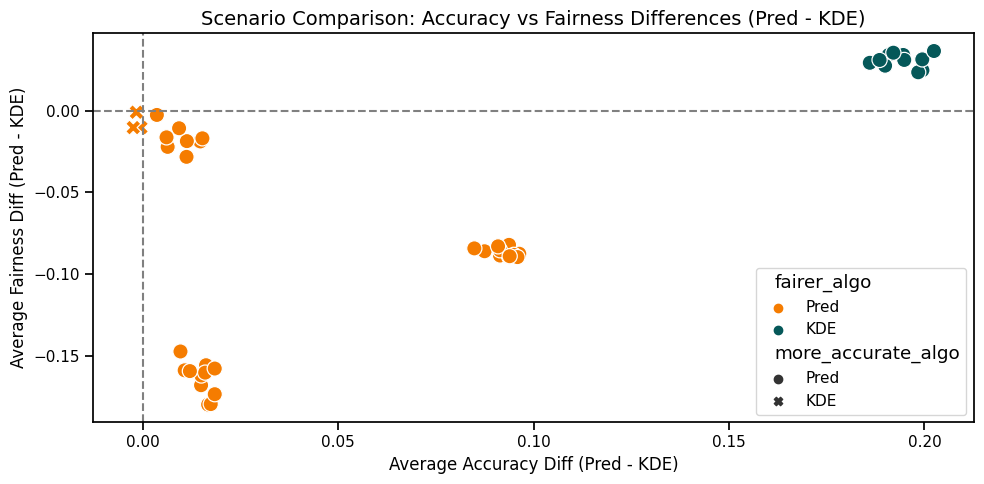

In [31]:
plt.figure(figsize=(10, 5)) 
sns.scatterplot(
    data=weekly_scenario_summary,
    x="avg_accuracy_diff",
    y="avg_fairness_diff",
    hue="fairer_algo",
    palette = palette_dict,
    s=120,
    style="more_accurate_algo"
)
plt.axhline(0, linestyle="--", color="gray")
plt.axvline(0, linestyle="--", color="gray")
plt.title("Scenario Comparison: Accuracy vs Fairness Differences (Pred - KDE)")
plt.xlabel("Average Accuracy Diff (Pred - KDE)")
plt.ylabel("Average Fairness Diff (Pred - KDE)")
# plt.legend(
#     bbox_to_anchor=(1.05, 1),
#     loc='upper left',
#     borderaxespad=0.
# )

plt.tight_layout()
    
save_title = f'AvgAccuracyDiff_Vs_AvgFairnessDiff_All'
plt.savefig(f'{RRF}/{save_title}.png')
plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
plt.show()


### Questions this plot answers:
#### Aim 1: Fairness and Accuracy Comparison
**1. How does KDE compare to PredPol in terms of fairness and accuracy across scenarios?** 

Again, in the weekly analysis here, we see that the average fairness gap difference is mostly negative across scenarios, indicating higher values for the fairness gap of KDE, meaning PredPol is usually fairer, and all but a few data points are showing higher accuracy for PredPol.

**2. Are more accurate systems necessarily fairer?**

PredPol is usually fairer and more accurate, but then those teal circle data points represent scenarios where PredPol was more accurate on average while it was less fair.

---

## Answering Further Questions

In [32]:
kde_fair_df = weekly_scenario_summary[weekly_scenario_summary["fairer_algo"] == "KDE"]
total_kde_fair = len(kde_fair_df)*100/ len(weekly_scenario_summary)

pct_kde_fair_burglary = (kde_fair_df["crime_type"] == "BURGLARY").mean() * 100
pct_kde_fair_400police = (kde_fair_df["number_of_police"] == 400).mean() * 100

print(f"KDE is fairer in {total_kde_fair}% of scenarios.")
print(f"Of those, {pct_kde_fair_burglary:.1f}% involve BURGLARY.")
print(f"Of those, {pct_kde_fair_400police:.1f}% have 400 officers.")


KDE is fairer in 25.0% of scenarios.
Of those, 100.0% involve BURGLARY.
Of those, 100.0% have 400 officers.


In [33]:
kde_acc_df = weekly_scenario_summary[weekly_scenario_summary["more_accurate_algo"] == "KDE"]
total_kde_acc = len(kde_acc_df)*100/ len(weekly_scenario_summary)

pct_kde_acc_burglary = (kde_acc_df["crime_type"] == "BURGLARY").mean() * 100
pct_kde_acc_40police = (kde_acc_df["number_of_police"] == 40).mean() * 100

print(f"KDE is more accurate in {total_kde_acc:.1f}% of scenarios.")
print(f"Of those, {pct_kde_acc_burglary:.1f}% involve BURGLARY.")
print(f"Of those, {pct_kde_acc_40police:.1f}% have 40 officers.")


KDE is more accurate in 6.8% of scenarios.
Of those, 100.0% involve BURGLARY.
Of those, 100.0% have 40 officers.


## Top 20 Neighborhood

Here we are having a closer look at Baltimore's top 20 neighborhoods in terms of average police share assignment throughout the days of simulation in a scenario.

In [34]:
def plot_neighborhood_stats(pMethod="Daily", pRep= 1.0, pNum= 400, cType="BURGLARY", alg="Pred"):    
    data = master_df[
        (master_df["crime_type"] == cType) &
        (master_df["number_of_police"] == pNum) &
        (master_df["pReport"] == pRep) &
        (master_df["prediction_method"]== pMethod)&
        (master_df["Algorithm"]== alg)
    ].copy()
    
    neighborhood_stats = data.groupby("Neighborhood").agg(
        total_days=("Date", "nunique"),
        over_policed_days=("over_policed", "sum"),
        avg_police_share=("police_share", "mean"),
        Race=("Race", "first")  
    ).reset_index()
    
    plt.figure(figsize=(10, 6))
    top_neighs = neighborhood_stats.sort_values("avg_police_share", ascending=False).head(20)
    sns.barplot(data=top_neighs, x="Neighborhood", y="avg_police_share", hue="Race", palette=palette_dict,dodge=False)
    plt.title("Top 20 Neighborhoods by Average Police Share")
    plt.ylabel("Average Police Share")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    save_title = f'Top20HeavilyPoliced_{pMethod}_{alg}_{pRep}_{cType}_{pNum}'
    plt.savefig(f'{RRF}/{save_title}.png')
    plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
    plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


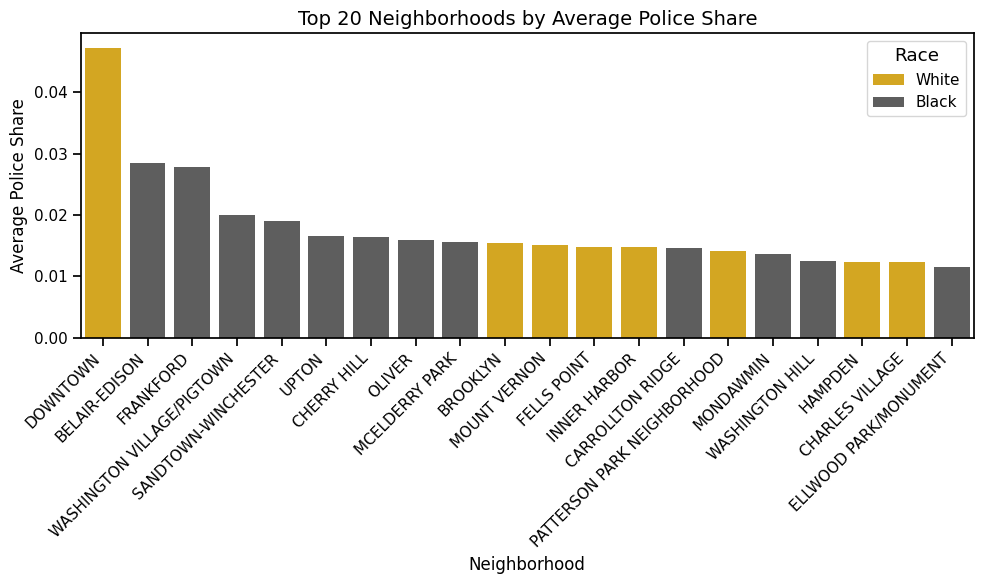

In [35]:
plot_neighborhood_stats(pMethod="Daily", pRep= 0.4, pNum= 400, cType="TOTAL", alg="KDE")


We have looked at daily concentrations and the temporal trends of officer assignment shares to Black vs. White neighborhoods before. This time we are checking out average police share to the top 20 neighborhoods through out the days of the simulation.

### Questions this plot answers:
#### Aim 6: Baltimore-Specific Questions and Insights
**1. Are police consistently concentrated in racially defined neighborhoods (Black-majority, White-majority, or Other), and if so, which group receives more attention?**

Looking at this diagram over different scenarios, we see that when reported crimes are used (pReport = 0.4), with **burglary records**, PredPol's top 20 neighborhoods in terms of police share assigned are more balanced between black and white neighborhoods (13 to 7) compared to KDE, With Brooklyn, a white neighborhood, having the highest share (almost 0.03).
KDE, on the other hand, has a 16 to 4 ratio for the top 20's black and white assignment, with Washington Village and Carrollton Ridge as the top 2, with about 0.05 and 0.04 police share, respectively.

Using **total crime records**, however, the top 20 neighborhoods in terms of average police share include as many Black neighborhoods as white, with Downtown, which is dominated by White resident getting twice as much of the share as others (about 0.035).

KDE is also having most of the officers focused in Downtown with a higher share compared to PredPol (almost 0.05). It is noticeably more imbalanced with a 12 to 8 ratio of Black to White neighborhoods in its top 20 assignments.

**2. Are these outcomes explainable by the number of neighborhoods per group, or do they reflect preferential targeting?**

yes, for this diagram more black neighborhoods could appear on top 20 because there are more of them in general in Baltimore

---


## Top 5 Neighborhoods and their percentage appearance (bar plot)

In this barplot we are checking out percentage of scenarios top 5 neighborhoods are appearing in each rank.

In [36]:
scenario_cols = ["Algorithm", "prediction_method", "crime_type", "number_of_police", "pReport"]

daily_master_df = master_df[master_df["prediction_method"]=="Daily"]

top_neigh_records = []
for scenario_id, group in daily_master_df.groupby(scenario_cols):
    grouped = group.groupby("Neighborhood").agg(
        avg_police_share=("police_share", "mean"),
        Race=("Race", "first")
    ).reset_index()
    
    grouped = grouped.sort_values("avg_police_share", ascending=False).head(5)
    grouped["Rank"] = range(1, len(grouped)+1)
    
    for _, row in grouped.iterrows():
        top_neigh_records.append({
            **dict(zip(scenario_cols, scenario_id)),
            "Neighborhood": row["Neighborhood"],
            "Rank": row["Rank"],
            "avg_police_share": row["avg_police_share"],
            "Race": row["Race"]
        })

top_neigh_df = pd.DataFrame(top_neigh_records)

def categorize_rank(rank):
    if rank == 1:
        return "Top 1"
    elif rank == 2:
        return "Top 2"
    else:
        return "Top 3–5"

top_neigh_df["RankCategory"] = top_neigh_df["Rank"].apply(categorize_rank)


display(top_neigh_df)

,Algorithm,prediction_method,crime_type,number_of_police,pReport,Neighborhood,Rank,avg_police_share,Race,RankCategory
0,KDE,Daily,BURGLARY,40,0.0,CARROLLTON RIDGE,1,0.048554,Black,Top 1
1,KDE,Daily,BURGLARY,40,0.0,WASHINGTON VILLAGE/PIGTOWN,2,0.043475,Black,Top 2
2,KDE,Daily,BURGLARY,40,0.0,BROOKLYN,3,0.036157,White,Top 3–5
3,KDE,Daily,BURGLARY,40,0.0,FRANKFORD,4,0.035515,Black,Top 3–5
4,KDE,Daily,BURGLARY,40,0.0,PATTERSON PARK NEIGHBORHOOD,5,0.033714,White,Top 3–5
...,...,...,...,...,...,...,...,...,...,...
435,Pred,Daily,TOTAL,400,1.0,DOWNTOWN,1,0.037347,White,Top 1
436,Pred,Daily,TOTAL,400,1.0,BELAIR-EDISON,2,0.023839,Black,Top 2
437,Pred,Daily,TOTAL,400,1.0,FRANKFORD,3,0.023815,Black,Top 3–5
438,Pred,Daily,TOTAL,400,1.0,CANTON,4,0.017371,White,Top 3–5


In [48]:

top_neigh_df_kde= top_neigh_df[top_neigh_df["Algorithm"]=="KDE"].copy()
total_scenarios_kde = len(top_neigh_df_kde[scenario_cols].drop_duplicates())
display(top_neigh_df_kde)
print(total_scenarios)
rank_stats_kde = (
    top_neigh_df_kde.groupby(["Neighborhood", "RankCategory"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ["Top 1", "Top 2", "Top 3–5"]:
    if col in rank_stats_kde.columns:
        if col== "Top 3–5":
            rank_stats_kde[f"{col}_pct"] = 100/3 * rank_stats_kde[col] / total_scenarios_kde
        else:
            rank_stats_kde[f"{col}_pct"] = 100 * rank_stats_kde[col] / total_scenarios_kde
    else:
        rank_stats_kde[col] = 0
        rank_stats_kde[f"{col}_pct"] = 0.0
display(rank_stats_kde)



,Algorithm,prediction_method,crime_type,number_of_police,pReport,Neighborhood,Rank,avg_police_share,Race,RankCategory
0,KDE,Daily,BURGLARY,40,0.0,CARROLLTON RIDGE,1,0.048554,Black,Top 1
1,KDE,Daily,BURGLARY,40,0.0,WASHINGTON VILLAGE/PIGTOWN,2,0.043475,Black,Top 2
2,KDE,Daily,BURGLARY,40,0.0,BROOKLYN,3,0.036157,White,Top 3–5
3,KDE,Daily,BURGLARY,40,0.0,FRANKFORD,4,0.035515,Black,Top 3–5
4,KDE,Daily,BURGLARY,40,0.0,PATTERSON PARK NEIGHBORHOOD,5,0.033714,White,Top 3–5
...,...,...,...,...,...,...,...,...,...,...
215,KDE,Daily,TOTAL,400,1.0,DOWNTOWN,1,0.046278,White,Top 1
216,KDE,Daily,TOTAL,400,1.0,BELAIR-EDISON,2,0.028648,Black,Top 2
217,KDE,Daily,TOTAL,400,1.0,FRANKFORD,3,0.027062,Black,Top 3–5
218,KDE,Daily,TOTAL,400,1.0,WASHINGTON VILLAGE/PIGTOWN,4,0.020922,Black,Top 3–5


220


RankCategory,Neighborhood,Top 1,Top 2,Top 3–5,Top 1_pct,Top 2_pct,Top 3–5_pct
0,BELAIR-EDISON,0,20,2,0.000000,45.454545,1.515152
1,BROOKLYN,0,0,32,0.000000,0.000000,24.242424
2,CARROLLTON RIDGE,6,16,0,13.636364,36.363636,0.000000
3,CHERRY HILL,0,0,1,0.000000,0.000000,0.757576
4,DOWNTOWN,22,0,11,50.000000,0.000000,8.333333
5,FRANKFORD,0,2,42,0.000000,4.545455,31.818182
6,PATTERSON PARK NEIGHBORHOOD,0,0,11,0.000000,0.000000,8.333333
7,SANDTOWN-WINCHESTER,0,0,11,0.000000,0.000000,8.333333
8,WASHINGTON VILLAGE/PIGTOWN,16,6,22,36.363636,13.636364,16.666667


In [49]:
top_neigh_df_pred= top_neigh_df[top_neigh_df["Algorithm"]=="Pred"].copy()
total_scenarios_pred = len(top_neigh_df_pred[scenario_cols].drop_duplicates())
rank_stats_pred = (
    top_neigh_df_pred.groupby(["Neighborhood", "RankCategory"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
for col in ["Top 1", "Top 2", "Top 3–5"]:
    if col in rank_stats_pred.columns:
        if col == "Top 3–5":
            rank_stats_pred[f"{col}_pct"] = 100/3 * rank_stats_pred[col] / total_scenarios_pred
        else:
            rank_stats_pred[f"{col}_pct"] = 100 * rank_stats_pred[col] / total_scenarios_pred
    else:
        rank_stats_pred[col] = 0
        rank_stats_pred[f"{col}_pct"] = 0.0
display(rank_stats_pred)

RankCategory,Neighborhood,Top 1,Top 2,Top 3–5,Top 1_pct,Top 2_pct,Top 3–5_pct
0,BELAIR-EDISON,0,11,33,0.000000,25.000000,25.000000
1,BROOKLYN,17,2,24,38.636364,4.545455,18.181818
2,CANTON,0,0,20,0.000000,0.000000,15.151515
3,CHERRY HILL,5,15,4,11.363636,34.090909,3.030303
4,COLDSTREAM HOMESTEAD MONTEBELLO,0,0,1,0.000000,0.000000,0.757576
5,DOWNTOWN,22,0,2,50.000000,0.000000,1.515152
6,FRANKFORD,0,16,28,0.000000,36.363636,21.212121
7,MCELDERRY PARK,0,0,19,0.000000,0.000000,14.393939
8,SANDTOWN-WINCHESTER,0,0,1,0.000000,0.000000,0.757576


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


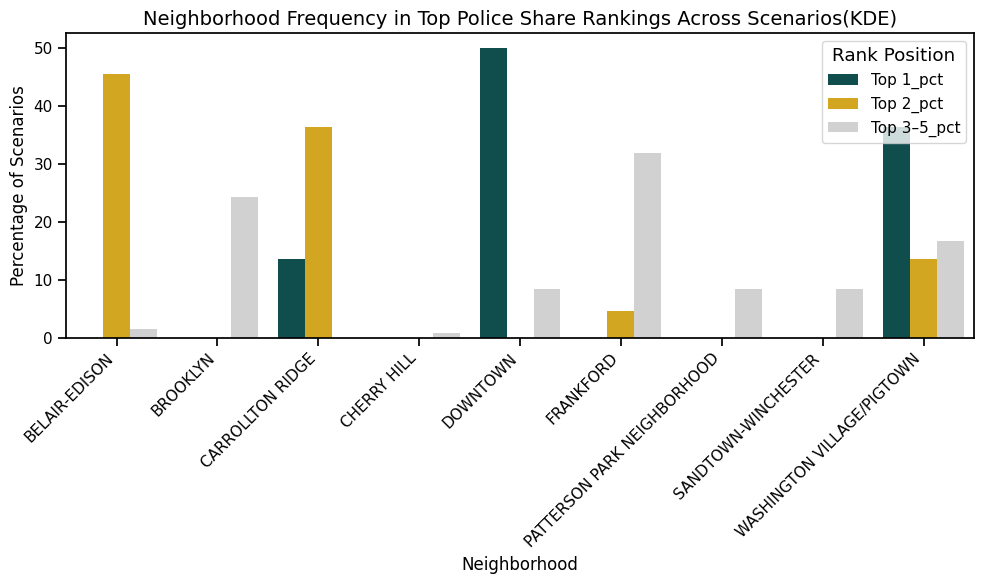

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


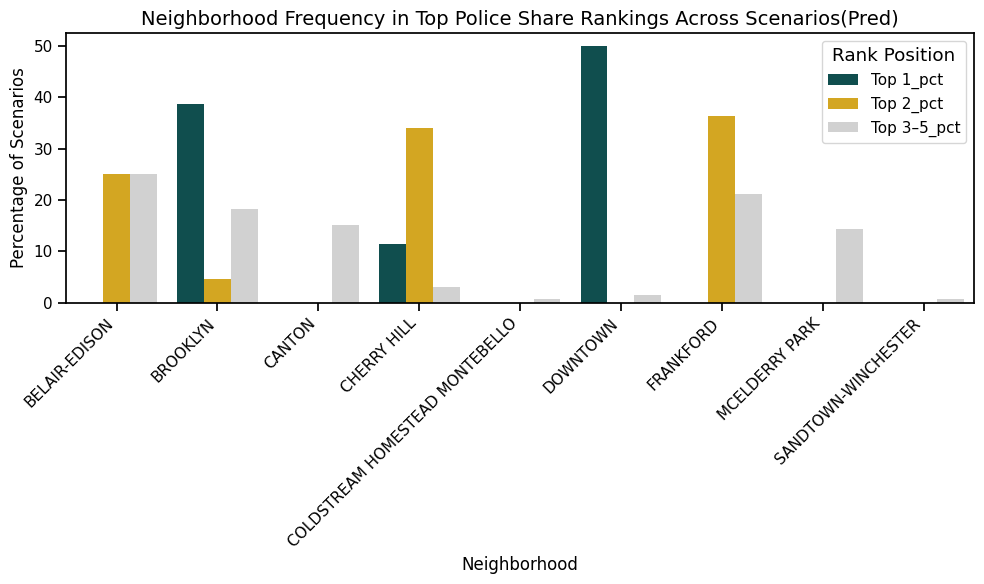

In [50]:
for algo,df in {"KDE":rank_stats_kde, "Pred":rank_stats_pred}.items():
    rank_long = df.melt(
        id_vars="Neighborhood",
        value_vars=["Top 1_pct", "Top 2_pct", "Top 3–5_pct"],
        var_name="Rank Position",
        value_name="Percentage"
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=rank_long,
        x="Neighborhood",
        y="Percentage",
        hue="Rank Position",
        palette=[COLORS[2],COLORS[0],COLORS[4]]
    )
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Neighborhood Frequency in Top Police Share Rankings Across Scenarios({algo})")
    plt.ylabel("Percentage of Scenarios")
    plt.xlabel("Neighborhood")
    plt.tight_layout()

    save_title = f'Top5HeavilyPoliced_Daily_{algo}'
    plt.savefig(f'{RRF}/{save_title}.png')
    plt.savefig(f'{RRF}/{save_title}.eps', format='eps')
    plt.show()


### Questions this plot answers:
#### Aim 6: Baltimore-Specific Questions and Insights

**3. Are there specific neighborhoods that are consistently getting highest police-shares, regardless of the model used?**

As we look at the average police share throughout the days of the simulation in each scenario, using **KDE**, Downtown, Washington Village/Pigtown, and Carrollton are appearing as receiving top shares in about 50, 38, and 12 percent of scenarios, respectively. </br>
**PredPol** is also giving the highest share to Downtown, followed by Brooklyn and Cherry Hill, with about 50, 40, and 10 percent share, respectively.

**Second-ranked neighborhoods**, in order of number of appearances in different scenarios for **KDE**, are Blair-Edison, Carrollton Ridge, Washington Village, and Frankford. </br>
For **PredPol**, the second ranks in order of share percentage are Frankford, Cherry Hill, Blair-Edison, and Brooklyn.


## Results

**1. Fairness and Accuracy Comparison**

PredPol is generally more accurate than KDE across most scenarios.
Fairness varies: While PredPol is often fairer, KDE becomes fairer in some specific cases—particularly when using Burglary data and fewer officers (e.g., 40).
Higher accuracy does not guarantee fairness. Both fair and unfair outcomes were observed across the fairness spectrum for high-accuracy scenarios.

**2. Temporal Feedback Loop Effects**

Bias does not always amplify, but when it does, it amplifies differently for the two algorithms. Longer simulation time might be needed for some scenarios to show amplification. Our simulations were about 30 days each.
KDE often shows more volatile or steeper trends in police allocation over time, especially with low reporting probability and fewer officers.
PredPol tends to be more stable in its allocation patterns, showing less susceptibility to feedback loop amplification.

**3. Crime Type Effect**

Burglary-based models exhibit stronger racial bias than those using all crime types.
KDE is more sensitive to the choice of crime type than PredPol. For example, when using all crimes, KDE allocates more to White neighborhoods, but flips to Black neighborhoods when using burglaries.

**4. Under-Reporting Impact**

Looking at some of the diagrams we couldn't conclude on this matter. However just comparing police standard deviation accross scenarios indicated low pReport values (e.g., 0.0) exacerbate bias—especially for KDE—which then may allocate resources disproportionately to White neighborhoods.
PredPol still favors Black neighborhoods in most scenarios, even with low reporting, but the gap may shrink or reverse in specific settings.

**5. Data-Driven vs Model-Driven Bias**

Both data and model matter:
Same data fed into different models (KDE vs PredPol) produces different fairness outcomes.
Same model fed different data (burglary vs total crime) can flip the direction of bias.
KDE appears more data-sensitive, while PredPol exhibits more model-consistent behavior across different inputs.

**6. Baltimore-Specific Insights**

Black neighborhoods receive more police on average in most simulations—but this varies with crime type and algorithm.
In scenarios using all crime types, KDE with low officer numbers sometimes concentrates more police in White neighborhoods, especially when reporting is low.
These patterns are not solely explainable by neighborhood count (Baltimore has more Black than White neighborhoods), suggesting model behavior plays a larger role than geography alone.

**7. Neighborhood Consistency**

Downtown, Brooklyn, and Cherry Hill are repeatedly among the top neighborhoods receiving the highest police share.
This consistency across models suggests that some neighborhoods are structurally favored/targeted, regardless of the predictive algorithm.

## Conclusion
This study demonstrates that both model and training data profoundly shape fairness outcomes in algorithmic policing. While PredPol often provides higher accuracy and slightly more stable fairness trends, KDE's behavior is more variable and responsive to crime type and reporting levels. The findings from Baltimore show that biases are neither purely model- nor data-driven but influenced by both in racially diverse and structurally unequal urban contexts. Our results emphasize the need for localized fairness assessments, and cautious use of predictive policing tools in sensitive environments.

## References

[1] U.S. Equal Employment Opportunity Commission. (1979). *Uniform Guidelines on Employee Selection Procedures (UGESP)*. Federal Register, Vol. 44, No. 43. https://www.eeoc.gov/laws/guidance/questions-and-answers-about-uniform-guidelines-employee-selection-procedures

[2] Rahman, A., et al. (2022). *Towards a Unifying Fairness Framework*. arXiv:2209.03805.